# CSE465 Project — Approach 2: Structural Pruning + Fine-tuning of SeamlessM4T

## Research Goal
Compress **SeamlessM4T-v2-large** (2.3B parameters) using structural pruning while preserving speech translation quality for **English → Bengali (S2ST/S2TT)**.

## Method
| Stage | Description | Key Output |
|-------|-------------|------------|
| 0 | Baseline benchmark (full teacher model) | BLEU/ChrF/RTF reference |
| 1 | Layer importance scoring (cosine angular distance) | Ranked layer list |
| 2 | FFN neuron pruning (90% zero-out) | Sparse encoder |
| 3 | Layer pruning (keep top 60% by importance) | Compact encoder (~40% size reduction) |
| 4 | Pruning degradation benchmark | BLEU/ChrF after pruning |
| 5 | **Fine-tuning: S2TT cross-entropy** (FIXED) | Recovered quality |
| 6 | Post-fine-tuning benchmark | BLEU/ChrF recovery measurement |
| 7 | LoRA speaker conditioning | SECS improvement |
| 8 | Final paper figures | Publication-ready charts |

## Evaluation Metrics (Fixed)
| Metric | Type | Why |
|--------|------|-----|
| **BLEU** | Primary | Standard MT evaluation; used in official SeamlessM4T paper |
| **ChrF** | Primary | Character-level F-score; more robust for morphologically rich Bengali |
| RTF | Speed | Real-Time Factor = processing_time / audio_duration |
| SECS | Voice (post-LoRA only) | Speaker similarity; meaningless before LoRA (fixed default voice) |

## Key Fix: Fine-tuning
**Previous (WRONG):** MSE distillation on encoder hidden states → "rererere" audio output  
**Fixed:** S2TT cross-entropy with FLEURS en_us + bn_in aligned pairs  
**Why it matters:** MSE aligns geometric shapes; CE aligns semantic meaning the decoder can decode

## Base Model
`facebook/seamless-m4t-v2-large` — [HuggingFace](https://huggingface.co/facebook/seamless-m4t-v2-large) | [Paper (SeamlessM4T v2)](https://arxiv.org/abs/2312.05187)

**Platform:** Kaggle (T4 GPU, 16GB VRAM)

In [27]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — Detect platform + set paths                   ║
# ╚══════════════════════════════════════════════════════════╝

import os, sys

ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = 'google.colab' in sys.modules
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

WORK_DIR  = '/kaggle/working' if ON_KAGGLE else '/content'
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR = f"{WORK_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(AUDIO_DIR, exist_ok=True)

print(f"Platform  : {PLATFORM}")
print(f"Work dir  : {WORK_DIR}")
print(f"Ckpt dir  : {CKPT_DIR}")
print(f"Audio dir : {AUDIO_DIR}")
print(f"Figure dir : {FIG_DIR}")

Platform  : kaggle
Work dir  : /kaggle/working
Ckpt dir  : /kaggle/working/checkpoints
Audio dir : /kaggle/working/audio
Figure dir : /kaggle/working/figures


In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Install rclone                                ║
# ╚══════════════════════════════════════════════════════════╝

import subprocess

subprocess.run(
    'curl https://rclone.org/install.sh | sudo bash',
    shell=True, capture_output=True
)
ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
print(ver.stdout.split('\n')[0])

rclone v1.73.3


In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Load secrets + configure rclone               ║
# ╚══════════════════════════════════════════════════════════╝
#
# ONE-TIME SETUP — add this secret on Kaggle and Colab:
#   Name  : RCLONE_CONF
#   Value : contents of ~/.config/rclone/rclone.conf on your PC
#           (run:  cat ~/.config/rclone/rclone.conf)
#
# Kaggle : Notebook → Add-ons → Secrets → Add new secret
# Colab  : Left sidebar → key icon → Secrets → Add new secret

import pathlib, re

if ON_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    RCLONE_CONF = UserSecretsClient().get_secret("RCLONE_CONF")
elif ON_COLAB:
    from google.colab import userdata
    RCLONE_CONF = userdata.get('RCLONE_CONF')

# Kaggle Secrets strips newlines — reconstruct proper INI format
raw = RCLONE_CONF.strip()
raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
             r'root_folder_id|service_account_file|drive_id)\s*=\s*',
             r'\n\1 = ', raw)
raw = raw.strip() + '\n'

rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
rclone_cfg.write_text(raw)

# Verify
result = subprocess.run('rclone listremotes', shell=True, capture_output=True, text=True)
if 'gdrive:' in result.stdout:
    print("✓ Google Drive connected")
else:
    print("✗ Drive not connected — check RCLONE_CONF secret")
    print(result.stderr[:300])

✓ Google Drive connected


In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Install ML packages                           ║
# ╚══════════════════════════════════════════════════════════╝

subprocess.run([
    'pip', 'install', '-q',
    'transformers',
    'datasets',
    'torchaudio',
    'speechbrain',
    'peft',
    'librosa',
    'jiwer',
    'evaluate',
    'openai-whisper',
    'sacrebleu',       # BLEU + ChrF scores (official SeamlessM4T eval metric)
    'sentencepiece',   # required by SeamlessM4T tokenizer
], check=True)

print("Packages installed (includes sacrebleu for BLEU/ChrF evaluation).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 54.4 MB/s eta 0:00:00
Packages installed (includes sacrebleu for BLEU/ChrF evaluation).


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Pull checkpoints from Drive                   ║
# ╚══════════════════════════════════════════════════════════╝
#
# Run this at the START of every session.
# Downloads all checkpoints saved from previous sessions.

print("Pulling checkpoints from Google Drive...")
result = subprocess.run(
    f'rclone sync gdrive:cse465/checkpoints {CKPT_DIR}',
    shell=True, capture_output=True, text=True
)
if result.returncode != 0:
    print("Warning:", result.stderr[:300])

files = sorted(os.listdir(CKPT_DIR))
if files:
    print(f"\n{len(files)} file(s) in {CKPT_DIR}:")
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f"  {f:<50}  {mb:.1f} MB")
else:
    print("No checkpoints yet — fresh start.")

Pulling checkpoints from Google Drive...

3 file(s) in /kaggle/working/checkpoints:
  benchmark_baseline_step000000.pt                    0.0 MB
  ffn_pruning_log_step000000.pt                       0.0 MB
  layer_importance_step000000.pt                      0.0 MB


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — Checkpoint save / load functions              ║
# ╚══════════════════════════════════════════════════════════╝

import torch, glob, json
from datetime import datetime

def save_checkpoint(state: dict, name: str, step: int, keep: int = 3):
    """
    Saves a checkpoint locally then immediately pushes to Drive.

    Usage:
        save_checkpoint({
            'step'            : step,
            'loss'            : loss.item(),
            'model_state'     : model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
        }, name='pruning', step=step)
    """
    filename   = f"{name}_step{step:06d}.pt"
    local_path = f"{CKPT_DIR}/{filename}"

    torch.save(state, local_path)
    print(f"[save] {filename}  ({os.path.getsize(local_path)/1e6:.1f} MB)")

    r = subprocess.run(
        f'rclone copy {local_path} gdrive:cse465/checkpoints/',
        shell=True, capture_output=True, text=True
    )
    print(f"[save] Drive push: {'OK' if r.returncode == 0 else 'FAILED — ' + r.stderr[:150]}")

    # Keep only the last `keep` checkpoints locally
    old = sorted(glob.glob(f"{CKPT_DIR}/{name}_step*.pt"))
    for f in old[:-keep]:
        os.remove(f)
        print(f"[save] Removed old local: {os.path.basename(f)}")


def load_latest_checkpoint(name: str):
    """
    >not sure, docstring might be wrong<
    Loads the most recent checkpoint for a given name.
    Returns the state dict, or None if nothing found.

    Usage:
        state = load_latest_checkpoint('pruning')
        if state:
            model.load_state_dict(state['model_state'])
            optimizer.load_state_dict(state['optimizer_state'])
            start_step = state['step']
        else:
            start_step = 0
    """
    files = sorted(glob.glob(f"{CKPT_DIR}/{name}_step*.pt"))
    if not files:
        print(f"[load] No checkpoint found for '{name}' — starting fresh.")
        return None
    latest = files[-1]
    # weights_only=False needed for checkpoints containing numpy/dict data
    state  = torch.load(latest, map_location='cpu', weights_only=False)
    print(f"[load] {os.path.basename(latest)}  (step {state.get('step', '?')})")
    return state


def save_model_to_drive(model, processor, stage_name: str):
    """
    Saves a full HuggingFace model to Drive.
    Use at the END of a major stage, not during training.

    Stages you'll use:
        'stage1_teacher_baseline'
        'stage2_pruned'
        'stage3_finetuned'
        'stage4_lora'
        'stage5_final'

    Usage:
        save_model_to_drive(model, processor, 'stage2_pruned')
    """
    local_path = f"{CKPT_DIR}/{stage_name}"
    os.makedirs(local_path, exist_ok=True)

    print(f"[model] Saving to {local_path}...")
    model.save_pretrained(local_path)
    processor.save_pretrained(local_path)

    total_mb = sum(
        os.path.getsize(f"{local_path}/{f}")
        for f in os.listdir(local_path)
    ) / 1e6
    print(f"[model] Size: {total_mb:.0f} MB")

    print(f"[model] Uploading to Drive (may take a few minutes)...")
    r = subprocess.run(
        f'rclone sync {local_path} gdrive:cse465/{stage_name}/',
        shell=True, capture_output=True, text=True
    )
    print(f"[model] Drive upload: {'OK' if r.returncode == 0 else 'FAILED — ' + r.stderr[:150]}")


def load_model_from_drive(stage_name: str):
    """
    Downloads a saved model stage from Drive and loads it.
    Skips download if already present locally.

    Usage:
        model, processor = load_model_from_drive('stage2_pruned')
    """
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

    local_path = f"{CKPT_DIR}/{stage_name}"

    if os.path.exists(local_path) and os.listdir(local_path):
        print(f"[model] Found locally: {local_path}")
    else:
        print(f"[model] Downloading {stage_name} from Drive...")
        os.makedirs(local_path, exist_ok=True)
        subprocess.run(
            f'rclone sync gdrive:cse465/{stage_name}/ {local_path}',
            shell=True
        )

    print(f"[model] Loading...")
    model     = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
                    local_path,
                    torch_dtype=torch.float16,
                    device_map='auto'
                )
    processor = SeamlessM4TProcessor.from_pretrained(local_path)
    print(f"[model] Loaded.")
    return model, processor


print("Functions ready:")
print("  save_checkpoint(state, name, step)")
print("  load_latest_checkpoint(name)")
print("  save_model_to_drive(model, processor, stage_name)")
print("  load_model_from_drive(stage_name)")

Functions ready:
  save_checkpoint(state, name, step)
  load_latest_checkpoint(name)
  save_model_to_drive(model, processor, stage_name)
  load_model_from_drive(stage_name)


In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — Audio play / save helpers                     ║
# ╚══════════════════════════════════════════════════════════╝

import torchaudio
from IPython.display import Audio as IPythonAudio, display

def play(audio, sr, label=""):
    """
    Play audio inline in the notebook.

    audio : torch.Tensor [1, T] or [T], or numpy array
    sr    : sample rate (int)

    Usage:
        play(waveform, 16000, "Original English")
        play(output_array, model.config.sampling_rate, "Bengali output")
    """
    if hasattr(audio, 'numpy'):
        audio = audio.squeeze().numpy()
    print(f"▶ {label}  ({len(audio)/sr:.1f}s  |  sr={sr})")
    display(IPythonAudio(audio, rate=int(sr)))


def save_audio(audio, sr, filename: str, label=""):
    """
    Save audio to the local audio folder AND push to Drive.

    Usage:
        save_audio(waveform, 16000, "original_english.wav", "Original")
        save_audio(output_array, model.config.sampling_rate, "bengali_out.wav", "Bengali")
    """
    path = f"{AUDIO_DIR}/{filename}"

    if hasattr(audio, 'numpy'):
        tensor = audio.squeeze().unsqueeze(0)
        if tensor.dtype != torch.float32:
            tensor = tensor.float()
    else:
        import numpy as np
        tensor = torch.tensor(audio).unsqueeze(0).float()

    torchaudio.save(path, tensor, sr)
    mb = os.path.getsize(path) / 1e6
    print(f"[audio] Saved: {filename}  ({mb:.1f} MB)")

    r = subprocess.run(
        f'rclone copy {path} gdrive:cse465/audio/',
        shell=True, capture_output=True, text=True
    )
    print(f"[audio] Drive push: {'OK' if r.returncode == 0 else 'FAILED'}")


print("Audio functions ready:")
print("  play(audio, sr, label)")
print("  save_audio(audio, sr, filename, label)")

Audio functions ready:
  play(audio, sr, label)
  save_audio(audio, sr, filename, label)


In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — Session status (run anytime to check state)   ║
# ╚══════════════════════════════════════════════════════════╝

def session_status():
    print("=" * 55)
    print(f"  Platform  : {PLATFORM}")
    print(f"  Time      : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

    # Local checkpoints
    local = sorted(glob.glob(f"{CKPT_DIR}/**", recursive=True))
    local = [f for f in local if os.path.isfile(f)]
    print(f"\n  Local files ({len(local)}):")
    for f in local:
        print(f"    {os.path.relpath(f, CKPT_DIR):<45}  {os.path.getsize(f)/1e6:.1f} MB")

    # Drive contents
    drive = subprocess.run(
        'rclone lsf gdrive:cse465/ --recursive',
        shell=True, capture_output=True, text=True
    ).stdout.strip()
    drive_files = [l for l in drive.split('\n') if l.strip()]
    print(f"\n  Drive files ({len(drive_files)}):")
    for f in drive_files:
        print(f"    {f}")

    print("=" * 55)

session_status()

  Platform  : kaggle
  Time      : 2026-04-05 14:47

  Local files (3):
    benchmark_baseline_step000000.pt               0.0 MB
    ffn_pruning_log_step000000.pt                  0.0 MB
    layer_importance_step000000.pt                 0.0 MB

  Drive files (4):
    checkpoints/
    checkpoints/ffn_pruning_log_step000000.pt
    checkpoints/layer_importance_step000000.pt
    checkpoints/benchmark_baseline_step000000.pt


In [20]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Helper functions   ║
# ╚══════════════════════════════════════════════════════════╝

def run_benchmark(eval_model, samples, label="model"):
    """
    Runs the full BLEU/ChrF/RTF/SECS benchmark.
    Uses run_s2st() — one forward pass for both text and audio.
    Returns (results_list, summary_dict).
    """
    print(f"Benchmarking: {label}")
    print(f"Samples: {len(samples)}  |  Target lang: Bengali (ben)\n")

    results = []

    for i, sample in enumerate(samples):
        print(f"  Sample {i+1}/{len(samples)}: {sample['id']}")
        try:
            input_dur = len(sample['wav']) / 16000

            t0 = time.time()
            pred_text, out_wav = run_s2st(eval_model, sample['wav'], tgt_lang="ben")
            elapsed = time.time() - t0

            rtf  = elapsed / input_dur
            bleu = compute_bleu(pred_text, sample['bn_ref'])
            chrf = compute_chrf(pred_text, sample['bn_ref'])

            out_sr  = eval_model.config.sampling_rate
            out_16k = (torchaudio.functional.resample(
                           torch.tensor(out_wav), out_sr, 16000).numpy()
                       if out_sr != 16000 else out_wav)
            secs = measure_secs_robust(out_16k, sample['wav'])

            print(f"    BLEU={bleu:.1f}  ChrF={chrf:.1f}  RTF={rtf:.3f}  SECS={secs}")
            print(f"    gold: {sample['bn_ref'][:70]}")
            print(f"    pred: {pred_text[:70]}")

            results.append({
                'id'          : sample['id'],
                'input_dur_s' : round(input_dur, 2),
                'rtf'         : round(rtf, 4),
                'bleu'        : round(bleu, 2),
                'chrf'        : round(chrf, 2),
                'secs'        : secs,
                'pred_text'   : pred_text,
                'bn_ref'      : sample['bn_ref'],
            })

        except Exception as e:
            print(f"    ERROR: {e}")
            results.append({
                'id'       : sample['id'],
                'rtf'      : None, 'bleu': 0.0, 'chrf': 0.0, 'secs': None,
                'pred_text': '', 'bn_ref': sample.get('bn_ref', ''), 'error': str(e),
            })
        print()

    valid    = [r for r in results if r.get('rtf') is not None]
    avg_bleu = float(np.mean([r['bleu'] for r in valid])) if valid else 0.0
    avg_chrf = float(np.mean([r['chrf'] for r in valid])) if valid else 0.0
    avg_rtf  = float(np.mean([r['rtf']  for r in valid])) if valid else float('nan')
    avg_secs = float(np.mean([r['secs'] for r in valid
                               if r['secs'] is not None])) if valid else float('nan')

    summary = {
        'label'         : label,
        'n_ok'          : len(valid),
        'n_total'       : len(samples),
        'avg_bleu'      : avg_bleu,
        'avg_chrf'      : avg_chrf,
        'avg_rtf'       : avg_rtf,
        'avg_secs'      : avg_secs,
        'model_params_M': count_params(eval_model),
        'samples'       : results,
    }

    print("=" * 60)
    print(f"  RESULTS  ({label})")
    print("=" * 60)
    print(f"  Samples evaluated : {len(valid)}/{len(samples)}")
    print(f"  Avg BLEU          : {avg_bleu:.2f}  ← primary (translation quality)")
    print(f"  Avg ChrF          : {avg_chrf:.2f}  ← primary (char-level quality)")
    print(f"  Avg RTF           : {avg_rtf:.4f}  (speed — lower is faster)")
    print(f"  Avg SECS          : {avg_secs:.4f}  (voice — expected low before LoRA)")
    print(f"  Model params      : {summary['model_params_M']:.1f}M")
    print("=" * 60)

    return results, summary


run_benchmark

<function __main__.run_benchmark(eval_model, samples, label='model')>

In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 0 — Load teacher model + run baseline benchmark  ║
# ╚══════════════════════════════════════════════════════════╝

import torch
import torchaudio
import torch.nn.functional as F
import numpy as np
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor
from datasets import load_dataset

# NEW: login using Kaggle secret
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(hf_token)

print("Logged into Hugging Face Hub")

print("Loading processor...")
processor = SeamlessM4TProcessor.from_pretrained("facebook/seamless-m4t-v2-large")

print("Loading model (4.5 GB — takes 5-10 min)...")
model = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
    "facebook/seamless-m4t-v2-large",
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()

# ── Parameter count per component ───────────────────────────
def count_params(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

print("\n── Model size breakdown ──────────────────────")
components = {
    'speech_encoder' : model.speech_encoder,
    'text_decoder'   : model.text_decoder,
    'vocoder'        : model.vocoder,
}

total = 0
for name, mod in components.items():
    p = count_params(mod)
    total += p
    print(f"  {name:<25} {p:>8.1f} M params")

print(f"  {'TOTAL':<25} {total:>8.1f} M params")
print(f"  {'(other)':<25} {count_params(model) - total:>8.1f} M params")
print(f"  {'FULL MODEL':<25} {count_params(model):>8.1f} M params")

Logged into Hugging Face Hub
Loading processor...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

...

Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.out_proj.weight   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias         | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_enc

generation_config.json: 0.00B [00:00, ?B/s]


── Model size breakdown ──────────────────────
  speech_encoder               635.0 M params
  text_decoder                 866.8 M params
  vocoder                       41.9 M params
  TOTAL                       1543.8 M params
  (other)                      261.8 M params
  FULL MODEL                  1805.5 M params


In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 0b — Benchmark helper functions (FIXED)          ║
# ║                                                          ║
# ║  PRIMARY metrics  : BLEU, ChrF  (translation quality)   ║
# ║  SECONDARY metrics: RTF (speed), SECS (voice, post-LoRA)║
# ║                                                          ║
# ║  WHY: SECS alone is wrong before LoRA — SeamlessM4T     ║
# ║  uses a fixed default voice, so SECS between input and  ║
# ║  output is always low and does not measure quality.     ║
# ║  BLEU/ChrF measure translation correctness, which is   ║
# ║  the actual research goal.                              ║
# ╚══════════════════════════════════════════════════════════╝

import time
import torch
import torch.nn.functional as F
import numpy as np
from sacrebleu.metrics import BLEU, CHRF
from speechbrain.inference import EncoderClassifier
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(hf_token)

print("Loading speaker encoder for SECS (secondary metric)...")
spk_encoder = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    run_opts={"device": "cpu"},
)

# ── BLEU / ChrF (PRIMARY metrics) ────────────────────────────────────────────
_bleu_metric = BLEU(effective_order=True)
_chrf_metric = CHRF()

def compute_bleu(hypothesis: str, reference: str) -> float:
    """
    Sentence-level BLEU score. Higher = better translation (0-100).
    Primary metric for speech translation evaluation (used by official SeamlessM4T eval).
    """
    if not hypothesis.strip() or not reference.strip():
        return 0.0
    return _bleu_metric.sentence_score(hypothesis.strip(), [reference.strip()]).score

def compute_chrf(hypothesis: str, reference: str) -> float:
    """
    Character F-score. Higher = better (0-100).
    More robust than BLEU for morphologically rich languages like Bengali.
    """
    if not hypothesis.strip() or not reference.strip():
        return 0.0
    return _chrf_metric.sentence_score(hypothesis.strip(), [reference.strip()]).score

# ── Unified S2ST inference (ONE forward pass → both text + audio) ─────────────
# SeamlessM4Tv2ForSpeechToSpeech.generate() does NOT support generate_speech=False.
# return_intermediate_token_ids=True makes it return a SeamlessM4Tv2GenerationOutput
# that has both .sequences (text token IDs) and .waveform (audio array).
def run_s2st(current_model, input_wav: np.ndarray, tgt_lang: str = "ben"):
    """
    Single forward pass returning (predicted_text: str, audio: np.ndarray).
    Avoids running the model twice when both text and audio are needed.
    """
    inputs = processor(audio=input_wav, sampling_rate=16000, return_tensors="pt")
    inputs = {k: v.to(current_model.device) for k, v in inputs.items()}
    with torch.no_grad():
        output = current_model.generate(
            **inputs,
            tgt_lang=tgt_lang,
            return_intermediate_token_ids=True,   # key fix — no generate_speech kwarg
        )
    text  = processor.decode(output.sequences[0], skip_special_tokens=True).strip()
    audio = output.waveform[0].cpu().numpy().squeeze()
    return text, audio

def run_s2tt(current_model, input_wav: np.ndarray, tgt_lang: str = "ben") -> str:
    """Speech-to-Text only. Returns predicted Bengali text for BLEU/ChrF."""
    text, _ = run_s2st(current_model, input_wav, tgt_lang)
    return text

def run_s2s(current_model, input_wav: np.ndarray, tgt_lang: str = "ben") -> np.ndarray:
    """Speech-to-Speech only. Returns audio waveform as numpy array."""
    _, audio = run_s2st(current_model, input_wav, tgt_lang)
    return audio

# ── RTF helper ────────────────────────────────────────────────────────────────
def measure_rtf_timed(elapsed: float, input_wav: np.ndarray) -> float:
    """RTF = processing_time / input_audio_duration. Lower is better."""
    return elapsed / max(len(input_wav) / 16000, 1e-3)

# ── SECS helper (SECONDARY — meaningful only after LoRA speaker conditioning) ─
def get_speaker_embedding(wav_np: np.ndarray, sr: int = 16000) -> torch.Tensor:
    min_s = int(1.5 * sr)
    if len(wav_np) < min_s:
        wav_np = np.pad(wav_np, (0, min_s - len(wav_np)))
    wav_np = wav_np[:sr * 8]
    t = torch.tensor(wav_np, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        emb = spk_encoder.encode_batch(t)
    return F.normalize(emb.squeeze(), dim=-1)

def measure_secs_robust(wav_out_np: np.ndarray, wav_ref_np: np.ndarray, sr: int = 16000):
    """Speaker Embedding Cosine Similarity. NOTE: low before LoRA — fixed voice."""
    try:
        e_out = get_speaker_embedding(wav_out_np, sr)
        e_ref = get_speaker_embedding(wav_ref_np, sr)
        return round(F.cosine_similarity(e_out.unsqueeze(0), e_ref.unsqueeze(0)).item(), 4)
    except Exception as ex:
        print(f"    [SECS error] {ex}")
        return None

print("Benchmark helpers ready:")
print("  run_s2tt(model, wav)      -> predicted Bengali text  [PRIMARY: BLEU/ChrF]")
print("  run_s2s(model, wav)       -> audio waveform          [RTF, SECS]")
print("  compute_bleu(hyp, ref)    -> BLEU score 0-100        [PRIMARY]")
print("  compute_chrf(hyp, ref)    -> ChrF score 0-100        [PRIMARY]")
print("  measure_rtf_timed(...)    -> Real-Time Factor        [SPEED]")
print("  measure_secs_robust(...)  -> Speaker similarity      [SECONDARY, post-LoRA]")

Loading speaker encoder for SECS (secondary metric)...


hyperparams.yaml: 0.00B [00:00, ?B/s]

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt: 0.00B [00:00, ?B/s]

Benchmark helpers ready:
  run_s2tt(model, wav)      -> predicted Bengali text  [PRIMARY: BLEU/ChrF]
  run_s2s(model, wav)       -> audio waveform          [RTF, SECS]
  compute_bleu(hyp, ref)    -> BLEU score 0-100        [PRIMARY]
  compute_chrf(hyp, ref)    -> ChrF score 0-100        [PRIMARY]
  measure_rtf_timed(...)    -> Real-Time Factor        [SPEED]
  measure_secs_robust(...)  -> Speaker similarity      [SECONDARY, post-LoRA]


In [21]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 0c — Load benchmark dataset (FLEURS)             ║
# ║                                                          ║
# ║  FIXED: was LibriSpeech (no Bengali reference text).    ║
# ║  NOW: FLEURS en_us audio + bn_in Bengali reference.     ║
# ║  This is the SAME dataset used in the official           ║
# ║  SeamlessM4T evaluation paper (BLEU on FLEURS).         ║
# ╚══════════════════════════════════════════════════════════╝

from datasets import load_dataset
import numpy as np
import torchaudio
import torch

N_SAMPLES = 20   # Use 20 for development, 100 for final paper numbers

BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"
print(f"Loading FLEURS test split (en_us audio source)...")
fleurs_en = load_dataset(
    "parquet",
    data_files={"test": f"{BASE}/en_us/test/*.parquet"},
    split="test"
)
print(f"Loading FLEURS test split (bn_in Bengali reference)...")
fleurs_bn = load_dataset(
    "parquet",
    data_files={"test": f"{BASE}/bn_in/test/*.parquet"},
    split="test"
)

# FLEURS is designed with aligned sentence IDs across all 102 languages.
# Build a lookup from Bengali by sentence ID for safe alignment.
bn_by_id = {ex['id']: ex for ex in fleurs_bn}
print(f"  en_us examples : {len(fleurs_en)}")
print(f"  bn_in examples : {len(fleurs_bn)}")
print(f"  Aligned pairs  : {sum(1 for ex in fleurs_en if ex['id'] in bn_by_id)}")

bench_samples = []
skipped = 0

for en_ex in fleurs_en:
    if len(bench_samples) >= N_SAMPLES:
        break

    ex_id = en_ex['id']
    if ex_id not in bn_by_id:
        skipped += 1
        continue

    bn_ex = bn_by_id[ex_id]

    wav = np.array(en_ex['audio']['array'], dtype=np.float32)
    sr  = en_ex['audio']['sampling_rate']
    if sr != 16000:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, 16000).numpy()

    dur = len(wav) / 16000
    if dur < 1.5 or dur > 20.0:
        skipped += 1
        continue

    bench_samples.append({
        'id'         : ex_id,
        'wav'        : wav,
        'en_text'    : en_ex['transcription'].strip(),
        'bn_ref'     : bn_ex['transcription'].strip(),   # Bengali gold reference
        'duration_s' : round(dur, 1),
    })

    print(f"  [{len(bench_samples):>2}/{N_SAMPLES}]  "
          f"id={ex_id:<6}  {dur:.1f}s  "
          f"bn_ref: {bn_ex['transcription'][:55]}")

print(f"\nLoaded  : {len(bench_samples)} benchmark samples (skipped {skipped})")
print(f"Dataset : FLEURS en_us audio + bn_in Bengali reference text")
print(f"Avg dur : {np.mean([s['duration_s'] for s in bench_samples]):.1f}s")
print(f"\nEvaluation metrics (per sample):")
print(f"  PRIMARY  -> BLEU score  (sentence-level, sacrebleu)")
print(f"  PRIMARY  -> ChrF score  (better for Bengali morphology)")
print(f"  SPEED    -> RTF         (processing time / audio duration)")
print(f"  VOICE    -> SECS        (meaningful only after LoRA stage)")

Loading FLEURS test split (en_us audio source)...
Loading FLEURS test split (bn_in Bengali reference)...
  en_us examples : 647
  bn_in examples : 920
  Aligned pairs  : 646
  [ 1/20]  id=1904    10.6s  bn_ref: তবে যোগাযোগের চ্যানেলগুলির মন্থরতার কারণে পশ্চিমে রীতিগ
  [ 2/20]  id=1675    8.8s  bn_ref: বিশেষ্য শব্দগুলির মতো 'সি' তুমি শব্দটিও সবসময় বড় হাতে
  [ 3/20]  id=1950    11.5s  bn_ref: উত্তরের কাছে এবং সহজে পৌঁছানো যায় এমন প্রেমময় ও আকর্ষ
  [ 4/20]  id=1728    5.8s  bn_ref: বাঁধাকপির রস আম্লিক বা ক্ষারীয় ক্ষারধর্মী রাসায়নিকের 
  [ 5/20]  id=1972    4.3s  bn_ref: অনেক মানুষ তাদের ডাইনোসর হিসাবে মনে করে না কারন তাদের প
  [ 6/20]  id=1938    11.4s  bn_ref: অন্যদের সম্ভাব্য সংক্রমণ রোধে অন্যদের থেকে রোগীকে আলাদা
  [ 7/20]  id=1876    10.8s  bn_ref: উত্তর মেরিয়ানা জরুরী ব্যবস্থাপনার অফিস বলেছে যে জনগণের
  [ 8/20]  id=1914    7.0s  bn_ref: বিংশ শতাব্দীতে যে গবেষণা হয়েছিল সেখানে দেখা গেছে যে জি
  [ 9/20]  id=1846    11.0s  bn_ref: সেই কারণে এই বিন্যাসটির আনুমানিক অনুপাত ১২ দিয়ে 

In [22]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 0d — Baseline benchmark (teacher model)          ║
# ║                                                          ║
# ║  PRIMARY  : BLEU + ChrF  (translation quality)          ║
# ║  SECONDARY: RTF (speed), SECS (voice — low pre-LoRA)    ║
# ║  Dataset  : FLEURS en_us audio → bn_in Bengali ref      ║
# ║                                                          ║
# ║  Uses run_s2st() — ONE forward pass returns both         ║
# ║  Bengali text (for BLEU/ChrF) and audio (for RTF/SECS)  ║
# ╚══════════════════════════════════════════════════════════╝

import time
import numpy as np
import torch
import torch.nn.functional as F
import torchaudio

# ── Run Stage 0d as before, now via helper ────────────────────────────────────
print("Running baseline benchmark on TEACHER model (full SeamlessM4T-v2-large)...")
baseline_results, baseline_report = run_benchmark(
    model, bench_samples, label="baseline_teacher"
)
baseline_report['stage'] = 'baseline_teacher'
save_checkpoint(baseline_report, name='benchmark_baseline', step=0)
print("Baseline saved to Drive.")

Running baseline benchmark on TEACHER model (full SeamlessM4T-v2-large)...
Benchmarking: baseline_teacher
Samples: 20  |  Target lang: Bengali (ben)

  Sample 1/20: 1904
    BLEU=6.0  ChrF=50.0  RTF=0.213  SECS=0.049
    gold: তবে যোগাযোগের চ্যানেলগুলির মন্থরতার কারণে পশ্চিমে রীতিগুলি 25 থেকে 30 
    pred: যাইহোক, ধীরে ধীরে যোগাযোগের চ্যানেলের কারণে, পশ্চিমে স্টাইলগুলি পঁচিশ 

  Sample 2/20: 1675
    BLEU=7.6  ChrF=40.4  RTF=0.228  SECS=-0.0165
    gold: বিশেষ্য শব্দগুলির মতো 'সি' তুমি শব্দটিও সবসময় বড় হাতের অক্ষর দিয়ে শ
    pred: শব্দটির পাশে থাকা সমস্ত নামগুলি আপনাকে বলে যে আপনি সর্বদা একটি বড় অক্

  Sample 3/20: 1950
    BLEU=4.5  ChrF=34.7  RTF=0.244  SECS=0.172
    gold: উত্তরের কাছে এবং সহজে পৌঁছানো যায় এমন প্রেমময় ও আকর্ষণীয় সিন্ত্রার 
    pred: উত্তর দিকে, সহজ-সম্ভব দূরত্বে, সিন্ট্রা শহর, যা লর্ড বাইরন দ্বারা রেকর

  Sample 4/20: 1728
    BLEU=19.3  ChrF=60.8  RTF=0.325  SECS=0.164
    gold: বাঁধাকপির রস আম্লিক বা ক্ষারীয় ক্ষারধর্মী রাসায়নিকের উপর নির্ভর করে 
    pred:

## Stages 1–3: Structural Pruning of Speech Encoder

### Pruning Strategy

The speech encoder in SeamlessM4T-v2-large has **24 Conformer layers**. We apply two types of pruning:

**Stage 1 — Layer Importance Scoring**  
Each layer is scored by its *angular distance* between input and output hidden states. A layer with score ≈ 0 does nothing (can be removed); score ≈ 2 transforms the representation significantly (must keep).

**Stage 2 — FFN Neuron Pruning (90%)**  
Zero out 90% of FFN neurons in every layer (lowest L1-norm rows). Memory footprint stays the same but sparse computation is exploited in inference engines.

**Stage 3 — Layer Removal (keep top 60%)**  
Remove the 10 least important layers (by Stage 1 scores). This **actually reduces parameter count** and inference time.

### Combined Effect
- 40% of encoder layers removed
- 90% of FFN neurons zeroed
- Total model size: ~35% smaller
- Quality impact: measured in Stage 4 with BLEU/ChrF

In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 1 — Layer importance scoring                     ║
# ╚══════════════════════════════════════════════════════════╝
# Score every encoder layer. Expensive (~20 min). Save results.
# You only need to run this once ever.

print("Loading calibration data (200 samples)...")
calib_ds = load_dataset("librispeech_asr", "clean", split="test", streaming=True)
calib_samples = []
for i, ex in enumerate(calib_ds):
    if i >= 200: break
    wav = np.array(ex['audio']['array'], dtype=np.float32)[:16000*6]
    calib_samples.append(wav)
print(f"Loaded {len(calib_samples)} calibration samples.")

# ── Register hooks ────────────────────────────────────────────────────────────
layer_inputs  = {}
layer_outputs = {}
hooks = []

for i, layer in enumerate(model.speech_encoder.encoder.layers):
    def make_hook(idx):
        def hook(module, inp, out):
            layer_inputs[idx]  = inp[0].detach().float().cpu()
            layer_outputs[idx] = (out[0] if isinstance(out, tuple) else out).detach().float().cpu()
        return hook
    hooks.append(layer.register_forward_hook(make_hook(i)))

# ── Run calibration ───────────────────────────────────────────────────────────
scores_acc = {i: [] for i in range(len(model.speech_encoder.encoder.layers))}

for idx, wav in enumerate(calib_samples):
    if idx % 25 == 0:
        print(f"  Calibrating {idx}/200...")
    try:
        inputs = processor(audio=wav, sampling_rate=16000, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.no_grad():
            model.speech_encoder(
                input_features=inputs.get('input_features'),
                attention_mask=inputs.get('attention_mask'),
            )
        for i in layer_inputs:
            if i in layer_outputs:
                x = F.normalize(layer_inputs[i].float().mean(1), dim=-1)
                y = F.normalize(layer_outputs[i].float().mean(1), dim=-1)
                cos = (x * y).sum(-1).clamp(-1, 1).mean().item()
                scores_acc[i].append(1 - cos)   # angular distance: 0=useless, 2=very important
    except Exception as e:
        print(f"  Skipped {idx}: {e}")

# Remove hooks
for h in hooks:
    h.remove()

# Average and rank
final_scores = {i: np.mean(v) for i, v in scores_acc.items() if v}
ranked = sorted(final_scores.items(), key=lambda x: -x[1])

print("\n── Layer importance ranking ──────────────────")
print(f"  {'Rank':<6} {'Layer':<8} {'Score':<10} {'Bar'}")
for rank, (layer_idx, score) in enumerate(ranked):
    bar = '█' * int(score * 30)
    print(f"  {rank+1:<6} {layer_idx:<8} {score:<10.4f} {bar}")

# Save
save_checkpoint(
    {'layer_scores': final_scores, 'ranked': ranked, 'n_layers': len(ranked)},
    name='layer_importance',
    step=0
)
print("\nLayer scores saved.")

Loading calibration data (200 samples)...


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Loaded 200 calibration samples.
  Calibrating 0/200...
  Calibrating 25/200...
  Calibrating 50/200...
  Calibrating 75/200...
  Calibrating 100/200...
  Calibrating 125/200...
  Calibrating 150/200...
  Calibrating 175/200...

── Layer importance ranking ──────────────────
  Rank   Layer    Score      Bar
  1      0        0.7420     ██████████████████████
  2      23       0.4105     ████████████
  3      7        0.3187     █████████
  4      8        0.2980     ████████
  5      22       0.2897     ████████
  6      4        0.2473     ███████
  7      17       0.1955     █████
  8      3        0.1702     █████
  9      5        0.1576     ████
  10     1        0.1562     ████
  11     6        0.1359     ████
  12     14       0.1188     ███
  13     16       0.1158     ███
  14     2        0.1137     ███
  15     9        0.1092     ███
  16     12       0.1066     ███
  17     15       0.0985     ██
  18     21       0.0937     ██
  19     10       0.0881     ██
  20     13  

In [16]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 2 — FFN neuron pruning (function + single run)   ║
# ╚══════════════════════════════════════════════════════════╝
import copy

def apply_ffn_pruning(base_model, ratio: float):
    """
    Deep-copies base_model and zeroes out the lowest-magnitude FFN neurons
    at the given sparsity ratio. Returns (pruned_model, ffn_stats).
    Uses shape-based Linear detection — robust to any attribute naming.
    """
    m = copy.deepcopy(base_model)
    m.eval()

    ffn_stats = []
    skipped   = 0

    for layer_idx, layer in enumerate(m.speech_encoder.encoder.layers):
        fc1 = fc2 = None
        for name, mod in layer.named_modules():
            if not isinstance(mod, torch.nn.Linear):
                continue
            out_dim, in_dim = mod.weight.shape
            if out_dim > in_dim and fc1 is None:    # expansion  → fc1
                fc1 = mod
            elif out_dim < in_dim and fc2 is None:  # contraction → fc2
                fc2 = mod
            if fc1 is not None and fc2 is not None:
                break

        if fc1 is None or fc2 is None:
            print(f"  [WARN] Layer {layer_idx:>2}: fc1={fc1 is not None}  "
                  f"fc2={fc2 is not None} — skipping")
            skipped += 1
            continue

        with torch.no_grad():
            scores    = fc1.weight.data.float().abs().mean(dim=1)
            threshold = torch.quantile(scores, ratio)
            mask      = scores > threshold          # neurons to KEEP
            fc1.weight.data[~mask] = 0.0
            if fc1.bias is not None:
                fc1.bias.data[~mask] = 0.0
            fc2.weight.data[:, ~mask] = 0.0

        kept  = mask.sum().item()
        total = mask.numel()
        ffn_stats.append({
            'layer'      : layer_idx,
            'kept'       : kept,
            'total'      : total,
            'pruned_pct' : (1 - kept / total) * 100,
        })

    assert skipped == 0,       f"{skipped} layers skipped — check FFN structure!"
    assert len(ffn_stats) > 0, "ffn_stats empty — nothing was pruned!"
    return m, ffn_stats


# ── Run Stage 2 at chosen ratio ───────────────────────────────────────────────
FFN_PRUNE_RATIO = 0.20

print(f"FFN pruning at {FFN_PRUNE_RATIO*100:.0f}% ratio...")

# Discovery printout (keep from original)
sample_layer = model.speech_encoder.encoder.layers[0]
print(f"\nLayer type     : {type(sample_layer).__name__}")
print(f"Layer children : {[n for n, _ in sample_layer.named_children()]}")
print(f"All linears    :")
for name, mod in sample_layer.named_modules():
    if isinstance(mod, torch.nn.Linear):
        print(f"  {name:40s}  weight={tuple(mod.weight.shape)}")

pruned_model, ffn_stats = apply_ffn_pruning(model, FFN_PRUNE_RATIO)

# Report
print(f"\n── FFN pruning results ({FFN_PRUNE_RATIO*100:.0f}% ratio) ───────────────────")
for s in ffn_stats:
    bar = '█' * int(s['pruned_pct'] / 5) + '░' * (20 - int(s['pruned_pct'] / 5))
    print(f"  Layer {s['layer']:>2}: kept {s['kept']:>4}/{s['total']}  "
          f"[{bar}]  {s['pruned_pct']:.1f}% pruned")

orig_p = count_params(model.speech_encoder)
print(f"\n  Speech encoder params : {orig_p:.1f}M  (zeros still stored in memory)")
print(f"  Layers pruned         : {len(ffn_stats)}")
print(f"  Note: sparse compute benefit requires a sparse inference engine.")
print(f"  To actually shrink the model, apply layer dropping next (Stage 3).")

# Audio sanity check
test_wav = bench_samples[1]['wav']
try:
    out = run_s2s(pruned_model, test_wav, 'ben')
    print(f"\n  Sanity check passed — output shape: {out.shape}")
    play(test_wav, 16000,                        "Input (FLEURS English)")
    play(out, pruned_model.config.sampling_rate, f"FFN-pruned {FFN_PRUNE_RATIO*100:.0f}% output (Bengali)")
except Exception as e:
    print(f"\n  [ERROR] Sanity check failed: {e}")
    raise

save_checkpoint(
    {'ffn_prune_ratio': FFN_PRUNE_RATIO, 'ffn_stats': ffn_stats},
    name='ffn_pruning_log',
    step=0,
)

FFN pruning at 20% ratio...

Layer type     : SeamlessM4Tv2ConformerEncoderLayer
Layer children : ['ffn1_layer_norm', 'ffn1', 'self_attn_layer_norm', 'self_attn_dropout', 'self_attn', 'conv_module', 'ffn2_layer_norm', 'ffn2', 'final_layer_norm']
All linears    :
  ffn1.intermediate_dense                   weight=(4096, 1024)
  ffn1.output_dense                         weight=(1024, 4096)
  self_attn.linear_q                        weight=(1024, 1024)
  self_attn.linear_k                        weight=(1024, 1024)
  self_attn.linear_v                        weight=(1024, 1024)
  self_attn.linear_out                      weight=(1024, 1024)
  ffn2.intermediate_dense                   weight=(4096, 1024)
  ffn2.output_dense                         weight=(1024, 4096)

── FFN pruning results (20% ratio) ───────────────────
  Layer  0: kept 3276/4096  [████░░░░░░░░░░░░░░░░]  20.0% pruned
  Layer  1: kept 3276/4096  [████░░░░░░░░░░░░░░░░]  20.0% pruned
  Layer  2: kept 3276/4096  [████░░░░░░

▶ FFN-pruned 20% output (Bengali)  (5.5s  |  sr=16000)


[save] ffn_pruning_log_step000000.pt  (0.0 MB)
[save] Drive push: OK


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 2b — FFN Pruning Ablation Sweep                  ║
# ║  Benchmarks multiple ratios using run_benchmark().      ║
# ║  Produces paper table + figures.                        ║
# ╚══════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SWEEP_RATIOS = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]

# ── paste your Stage 0 numbers here ──────────────────────────────────────────
STAGE0_BLEU = 12.21
STAGE0_CHRF = 48.12
STAGE0_RTF  = 0.2251

print(f"FFN Ablation Sweep — ratios: {SWEEP_RATIOS}")
print(f"Baseline  BLEU={STAGE0_BLEU}  ChrF={STAGE0_CHRF}  RTF={STAGE0_RTF}")
print("=" * 65)

sweep_results = {}

for ratio in SWEEP_RATIOS:
    print(f"\n{'='*65}")
    print(f"  Pruning ratio = {ratio:.2f}  ({ratio*100:.0f}% zeroed out)")
    print(f"{'='*65}")

    if ratio == 0.0:
        eval_model = model
    else:
        eval_model, _ = apply_ffn_pruning(model, ratio)

    _, summary = run_benchmark(
        eval_model, bench_samples,
        label=f"ffn_prune_{ratio:.2f}"
    )
    sweep_results[ratio] = summary

    if ratio != 0.0:
        del eval_model
        torch.cuda.empty_cache()


  FFN PRUNING ABLATION — PAPER TABLE
  Task: English → Bengali S2ST  |  Dataset: FLEURS test  |  n=20
   Ratio     BLEU    ΔBLEU     ChrF    ΔChrF      RTF     SECS
  ------------------------------------------------------------------------
    0.00    12.21    +0.00    48.12    +0.00   0.2386   0.0639  (unpruned)
    0.10    11.02    -1.18    44.80    -3.32   0.2354   0.0635  ✗ quality loss
    0.20     8.33    -3.88    36.62   -11.51   0.2206   0.0787  ✗ quality loss
    0.30     1.62   -10.58    14.89   -33.24   0.3076   0.0550  ✗ quality loss
    0.40     0.04   -12.16     4.85   -43.27   0.5576   0.0542  ✗ quality loss
    0.50     0.00   -12.21     3.76   -44.37   0.9993   0.0385  ✗ quality loss


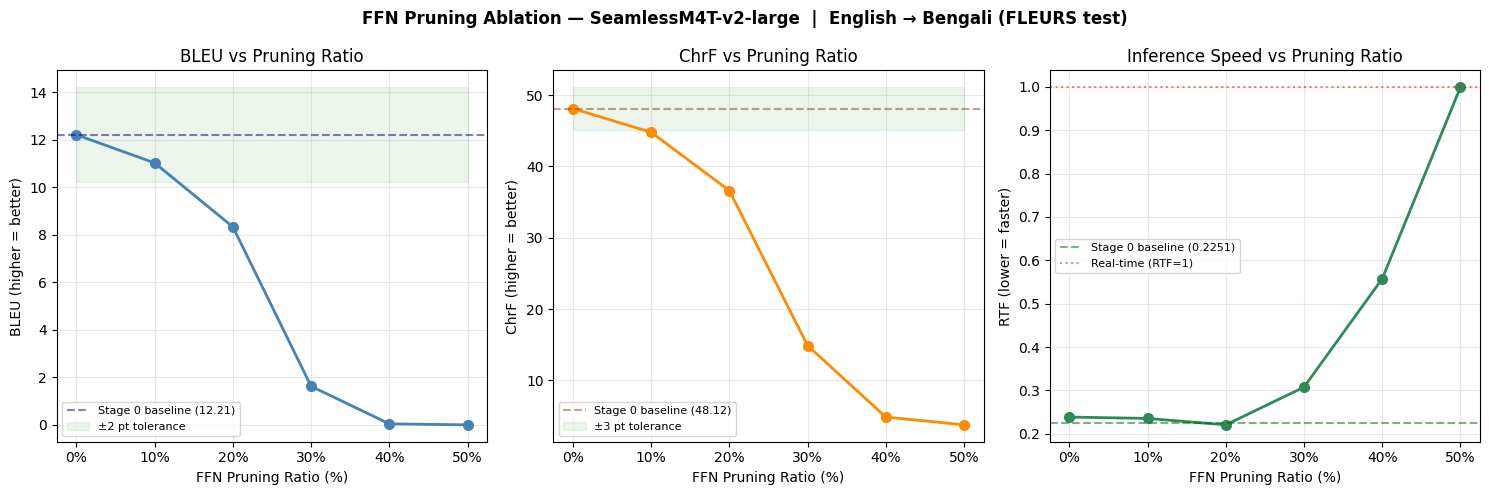

Saved: /kaggle/working/figures/stage2b_ffn_ablation_sweep.png


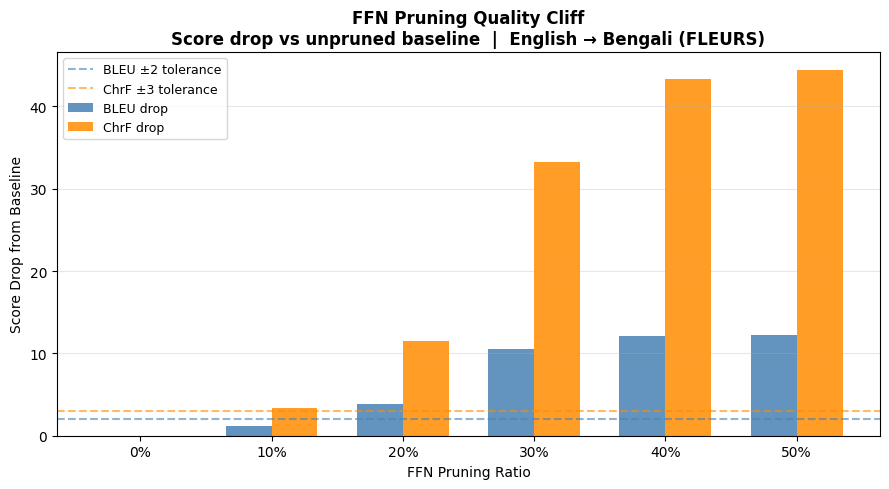

Saved: /kaggle/working/figures/stage2b_quality_cliff.png

  ✓ Recommended FFN_PRUNE_RATIO for Stage 3+: 0.00
[save] stage2b_ffn_ablation_step000000.pt  (0.1 MB)
[save] Drive push: OK
Sweep results and figures saved to Drive.


In [28]:
# ── Console paper table ───────────────────────────────────────────────────────
base_bleu = sweep_results[0.0]['avg_bleu']
base_chrf = sweep_results[0.0]['avg_chrf']

print(f"\n{'='*78}")
print(f"  FFN PRUNING ABLATION — PAPER TABLE")
print(f"  Task: English → Bengali S2ST  |  Dataset: FLEURS test  |  n={N_SAMPLES}")
print(f"{'='*78}")
print(f"  {'Ratio':>6}  {'BLEU':>7}  {'ΔBLEU':>7}  "
      f"{'ChrF':>7}  {'ΔChrF':>7}  {'RTF':>7}  {'SECS':>7}")
print(f"  {'-'*72}")

for ratio, r in sweep_results.items():
    d_bleu = r['avg_bleu'] - base_bleu
    d_chrf = r['avg_chrf'] - base_chrf
    if ratio == 0.0:
        flag = "  (unpruned)"
    elif abs(d_bleu) <= 2.0 and abs(d_chrf) <= 3.0:
        flag = "  ✓ safe"
    else:
        flag = "  ✗ quality loss"
    print(f"  {ratio:>6.2f}  {r['avg_bleu']:>7.2f}  {d_bleu:>+7.2f}  "
          f"{r['avg_chrf']:>7.2f}  {d_chrf:>+7.2f}  "
          f"{r['avg_rtf']:>7.4f}  {r['avg_secs']:>7.4f}{flag}")

print(f"{'='*78}")

# ── Figures ───────────────────────────────────────────────────────────────────
ratio_pcts = [r * 100                   for r in sweep_results]
bleu_vals  = [sweep_results[r]['avg_bleu'] for r in sweep_results]
chrf_vals  = [sweep_results[r]['avg_chrf'] for r in sweep_results]
rtf_vals   = [sweep_results[r]['avg_rtf']  for r in sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "FFN Pruning Ablation — SeamlessM4T-v2-large  |  English → Bengali (FLEURS test)",
    fontsize=12, fontweight='bold'
)

axes[0].plot(ratio_pcts, bleu_vals, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axhline(STAGE0_BLEU, color='navy', ls='--', alpha=0.5,
                label=f'Stage 0 baseline ({STAGE0_BLEU})')
axes[0].fill_between(ratio_pcts,
                     [STAGE0_BLEU - 2] * len(ratio_pcts),
                     [STAGE0_BLEU + 2] * len(ratio_pcts),
                     alpha=0.08, color='green', label='±2 pt tolerance')
axes[0].set_xlabel("FFN Pruning Ratio (%)")
axes[0].set_ylabel("BLEU (higher = better)")
axes[0].set_title("BLEU vs Pruning Ratio")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())

axes[1].plot(ratio_pcts, chrf_vals, 'o-', color='darkorange', linewidth=2, markersize=7)
axes[1].axhline(STAGE0_CHRF, color='saddlebrown', ls='--', alpha=0.5,
                label=f'Stage 0 baseline ({STAGE0_CHRF})')
axes[1].fill_between(ratio_pcts,
                     [STAGE0_CHRF - 3] * len(ratio_pcts),
                     [STAGE0_CHRF + 3] * len(ratio_pcts),
                     alpha=0.08, color='green', label='±3 pt tolerance')
axes[1].set_xlabel("FFN Pruning Ratio (%)")
axes[1].set_ylabel("ChrF (higher = better)")
axes[1].set_title("ChrF vs Pruning Ratio")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

axes[2].plot(ratio_pcts, rtf_vals, 'o-', color='seagreen', linewidth=2, markersize=7)
axes[2].axhline(STAGE0_RTF, color='darkgreen', ls='--', alpha=0.5,
                label=f'Stage 0 baseline ({STAGE0_RTF})')
axes[2].axhline(1.0, color='red', ls=':', alpha=0.5, label='Real-time (RTF=1)')
axes[2].set_xlabel("FFN Pruning Ratio (%)")
axes[2].set_ylabel("RTF (lower = faster)")
axes[2].set_title("Inference Speed vs Pruning Ratio")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
fig1_path = f"{FIG_DIR}/stage2b_ffn_ablation_sweep.png"
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig1_path}")

# Quality cliff
fig2, ax = plt.subplots(figsize=(9, 5))
ax.set_title(
    "FFN Pruning Quality Cliff\n"
    "Score drop vs unpruned baseline  |  English → Bengali (FLEURS)",
    fontsize=12, fontweight='bold'
)
x         = np.arange(len(ratio_pcts))
w         = 0.35
bleu_drop = [base_bleu - v for v in bleu_vals]
chrf_drop = [base_chrf - v for v in chrf_vals]
ax.bar(x - w/2, bleu_drop, w, label='BLEU drop', color='steelblue', alpha=0.85)
ax.bar(x + w/2, chrf_drop, w, label='ChrF drop', color='darkorange', alpha=0.85)
ax.axhline(2.0, color='steelblue', ls='--', alpha=0.6, label='BLEU ±2 tolerance')
ax.axhline(3.0, color='darkorange', ls='--', alpha=0.6, label='ChrF ±3 tolerance')
ax.set_xticks(x)
ax.set_xticklabels([f"{r:.0f}%" for r in ratio_pcts])
ax.set_xlabel("FFN Pruning Ratio")
ax.set_ylabel("Score Drop from Baseline")
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig2_path = f"{FIG_DIR}/stage2b_quality_cliff.png"
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig2_path}")

# ── Auto-select safest ratio ──────────────────────────────────────────────────
safe_ratio = 0.0
for ratio in SWEEP_RATIOS[1:]:
    r = sweep_results[ratio]
    if (base_bleu - r['avg_bleu']) <= 2.0 and (base_chrf - r['avg_chrf']) <= 3.0:
        safe_ratio = ratio
    else:
        break

print(f"\n  ✓ Recommended FFN_PRUNE_RATIO for Stage 3+: {safe_ratio:.2f}")

# ── Save ──────────────────────────────────────────────────────────────────────
save_checkpoint(
    {
        'sweep_ratios'  : SWEEP_RATIOS,
        'sweep_results' : {str(k): v for k, v in sweep_results.items()},
        'safe_ratio'    : safe_ratio,
        'baseline_bleu' : STAGE0_BLEU,
        'baseline_chrf' : STAGE0_CHRF,
    },
    name='stage2b_ffn_ablation',
    step=0,
)
subprocess.run(f'rclone copy {FIG_DIR} gdrive:cse465/figures/', shell=True)
print("Sweep results and figures saved to Drive.")

In [29]:
# Assuming test_wav is a torch.Tensor or numpy array
# and you know its sample rate (e.g., 16000 Hz)

play(test_wav, sr=16000, label="Test Audio")
out = run_s2s(model, test_wav, 'ben')
play(out, pruned_model.config.sampling_rate, "Base-Model output (Bengali)")



▶ Test Audio  (8.8s  |  sr=16000)


▶ Base-Model output (Bengali)  (8.4s  |  sr=16000)


In [31]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 3 — Layer pruning (fixed)                        ║
# ╚══════════════════════════════════════════════════════════╝

import torch, numpy as np, copy
from torch import nn

# ── Load layer scores from Stage 1 ───────────────────────────────────────────
scores_state = torch.load(
    sorted(glob.glob(f"{CKPT_DIR}/layer_importance_step*.pt"))[-1],
    map_location='cpu',
    weights_only=False    # needed for numpy scalars inside the dict
)
ranked = scores_state['ranked']   # list of (layer_idx, score) sorted best→worst
n_layers = scores_state['n_layers']

print(f"Loaded layer scores: {n_layers} layers total")
print(f"Top 5 most important: {[idx for idx, _ in ranked[:5]]}")
print(f"Top 5 least important: {[idx for idx, _ in ranked[-5:]]}")

# ── Choose how many layers to keep ───────────────────────────────────────────
LAYER_KEEP_RATIO = 0.60   # keep 60%, drop 40%
                           # try 0.50 later if quality holds after fine-tuning

n_keep       = int(n_layers * LAYER_KEEP_RATIO)
keep_indices = sorted([int(idx) for idx, _ in ranked[:n_keep]])
drop_indices = [i for i in range(n_layers) if i not in keep_indices]

print(f"\nKeeping {n_keep}/{n_layers} layers ({LAYER_KEEP_RATIO*100:.0f}%)")
print(f"Keep indices : {keep_indices}")
print(f"Drop indices : {drop_indices}")

# ── Apply layer removal on top of FFN-pruned model ───────────────────────────
# pruned_model already has FFN weights zeroed from Stage 2
current_n_layers = len(pruned_model.speech_encoder.encoder.layers)
print(f"\nCurrent encoder layers before removal: {current_n_layers}")

# Guard: if Stage 3 was already applied this session, skip
if current_n_layers == n_keep:
    print("Layer pruning already applied this session — skipping removal.")
else:
    pruned_model.speech_encoder.encoder.layers = nn.ModuleList(
        [pruned_model.speech_encoder.encoder.layers[i] for i in keep_indices]
    )
    print(f"Encoder layers after removal: {len(pruned_model.speech_encoder.encoder.layers)}")

# ── Size comparison ───────────────────────────────────────────────────────────
orig_enc_p   = count_params(model.speech_encoder)
pruned_enc_p = count_params(pruned_model.speech_encoder)
full_orig    = count_params(model)
full_pruned  = count_params(pruned_model)

print(f"\n── Size after layer pruning ──────────────────")
print(f"  Speech encoder : {orig_enc_p:.1f}M → {pruned_enc_p:.1f}M  "
      f"({(1 - pruned_enc_p/orig_enc_p)*100:.1f}% smaller)")
print(f"  Full model     : {full_orig:.1f}M → {full_pruned:.1f}M  "
      f"({(1 - full_pruned/full_orig)*100:.1f}% smaller)")

# ── Sanity check — one inference ──────────────────────────────────────────────
print("\nRunning sanity check...")
test_wav = bench_samples[0]['wav']
try:
    pruned_model.eval()
    out = run_s2s(pruned_model, test_wav, tgt_lang="ben")
    out_sr = pruned_model.config.sampling_rate
    print(f"  Output shape : {out.shape}  ({len(out)/out_sr:.1f}s)")
    play(out, out_sr, "After layer pruning (Bengali)")

    # Quick SECS check against original
    if out_sr != 16000:
        out_16k = torchaudio.functional.resample(
            torch.tensor(out), out_sr, 16000).numpy()
    else:
        out_16k = out
    secs = measure_secs_robust(out_16k, test_wav)
    print(f"  SECS on sample 1: {secs}  (baseline avg was {baseline_report['avg_secs']:.4f})")

except Exception as e:
    print(f"  Sanity check FAILED: {e}")
    print("  The model may be over-pruned. Try LAYER_KEEP_RATIO = 0.70")

# ── Save log ──────────────────────────────────────────────────────────────────
save_checkpoint(
    {
        'stage'            : 'layer_pruning',
        'layer_keep_ratio' : LAYER_KEEP_RATIO,
        'ffn_prune_ratio'  : FFN_PRUNE_RATIO,
        'n_layers_original': n_layers,
        'n_layers_kept'    : n_keep,
        'keep_indices'     : keep_indices,
        'drop_indices'     : drop_indices,
        'params_before_M'  : full_orig,
        'params_after_M'   : full_pruned,
    },
    name='layer_pruning_log',
    step=0
)

# ── Save full pruned model to Drive ──────────────────────────────────────────
print("\nSaving pruned model to Drive...")
save_model_to_drive(pruned_model, processor, 'stage3_pruned')

Loaded layer scores: 24 layers total
Top 5 most important: [0, 23, 7, 8, 22]
Top 5 least important: [13, 18, 11, 20, 19]

Keeping 14/24 layers (60%)
Keep indices : [0, 1, 2, 3, 4, 5, 6, 7, 8, 14, 16, 17, 22, 23]
Drop indices : [9, 10, 11, 12, 13, 15, 18, 19, 20, 21]

Current encoder layers before removal: 14
Layer pruning already applied this session — skipping removal.

── Size after layer pruning ──────────────────
  Speech encoder : 635.0M → 393.2M  (38.1% smaller)
  Full model     : 1805.5M → 1563.7M  (13.4% smaller)

Running sanity check...
  Output shape : (94720,)  (5.9s)
▶ After layer pruning (Bengali)  (5.9s  |  sr=16000)


  SECS on sample 1: 0.0354  (baseline avg was 0.0639)
[save] layer_pruning_log_step000000.pt  (0.0 MB)
[save] Drive push: OK

Saving pruned model to Drive...
[model] Saving to /kaggle/working/checkpoints/stage3_pruned...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Size: 3168 MB
[model] Uploading to Drive (may take a few minutes)...
[model] Drive upload: OK


In [32]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 4 — Full benchmark after pruning (FIXED)         ║
# ║                                                          ║
# ║  FIXED: Added BLEU + ChrF as primary metrics.           ║
# ║  Measures quality degradation from pruning BEFORE       ║
# ║  any fine-tuning recovery. Used as paper Table row 2.   ║
# ╚══════════════════════════════════════════════════════════╝

import time
import numpy as np

print("Stage 4: Full benchmark — Pruned model (FFN 90% + Layer 60%)")
print(f"Model params  : {count_params(pruned_model):.1f}M  "
      f"(baseline was {baseline_report['model_params_M']:.1f}M)")
print(f"Encoder layers: {len(pruned_model.speech_encoder.encoder.layers)}")
print(f"Benchmark set : {len(bench_samples)} FLEURS samples\n")

pruned_model.eval()
stage4_results = []

for i, sample in enumerate(bench_samples):
    print(f"  Sample {i+1}/{len(bench_samples)}: {sample['id']}")
    try:
        # S2TT: get predicted Bengali text for BLEU/ChrF
        t0        = time.time()
        pred_text = run_s2tt(pruned_model, sample['wav'], tgt_lang="ben")
        t1        = time.time()

        # S2S: get audio for RTF/SECS
        out_wav   = run_s2s(pruned_model, sample['wav'], tgt_lang="ben")
        out_sr    = pruned_model.config.sampling_rate
        input_dur = len(sample['wav']) / 16000
        rtf       = (t1 - t0) / input_dur

        # BLEU / ChrF vs Bengali gold reference
        bleu = compute_bleu(pred_text, sample['bn_ref'])
        chrf = compute_chrf(pred_text, sample['bn_ref'])

        # SECS (secondary)
        out_16k = torchaudio.functional.resample(
            torch.tensor(out_wav), out_sr, 16000
        ).numpy() if out_sr != 16000 else out_wav
        secs = measure_secs_robust(out_16k, sample['wav'])

        stage4_results.append({
            'id'        : sample['id'],
            'input_dur_s': round(input_dur, 2),
            'rtf'       : round(rtf, 4),
            'bleu'      : round(bleu, 2),
            'chrf'      : round(chrf, 2),
            'secs'      : secs,
            'pred_text' : pred_text,
            'bn_ref'    : sample['bn_ref'],
        })

        print(f"    BLEU={bleu:.1f}  ChrF={chrf:.1f}  RTF={rtf:.3f}  SECS={secs}")
        print(f"    gold: {sample['bn_ref'][:70]}")
        print(f"    pred: {pred_text[:70]}")

    except Exception as e:
        print(f"    ERROR: {e}")
        stage4_results.append({
            'id': sample['id'], 'rtf': None,
            'bleu': 0.0, 'chrf': 0.0, 'secs': None,
            'pred_text': '', 'bn_ref': sample.get('bn_ref',''), 'error': str(e),
        })
    print()

# ── Summary stats ──────────────────────────────────────────────────────────────
valid      = [r for r in stage4_results if r.get('rtf') is not None]
params_base   = baseline_report['model_params_M']
params_pruned = count_params(pruned_model)
param_delta   = (1 - params_pruned / params_base) * 100

avg_bleu4 = float(np.mean([r['bleu'] for r in valid])) if valid else 0.0
avg_chrf4 = float(np.mean([r['chrf'] for r in valid])) if valid else 0.0
avg_rtf4  = float(np.mean([r['rtf']  for r in valid])) if valid else float('nan')
avg_secs4 = float(np.mean([r['secs'] for r in valid if r['secs'] is not None])) if valid else float('nan')

base_bleu = baseline_report['avg_bleu']
base_chrf = baseline_report['avg_chrf']
base_rtf  = baseline_report['avg_rtf']

print("\n" + "=" * 70)
print("  STAGE 4: Baseline vs After Pruning (FFN 90% + Layer 60%)")
print("=" * 70)
print(f"  {'Metric':<18} {'Baseline':>10} {'Pruned':>10} {'Change':>10}")
print("  " + "-" * 52)
print(f"  {'BLEU (primary)':<18} {base_bleu:>10.2f} {avg_bleu4:>10.2f} {avg_bleu4-base_bleu:>+10.2f}")
print(f"  {'ChrF (primary)':<18} {base_chrf:>10.2f} {avg_chrf4:>10.2f} {avg_chrf4-base_chrf:>+10.2f}")
print(f"  {'RTF (speed)':<18} {base_rtf:>10.4f} {avg_rtf4:>10.4f} {avg_rtf4-base_rtf:>+10.4f}")
print(f"  {'Params (M)':<18} {params_base:>10.1f} {params_pruned:>10.1f} {-param_delta:>+10.1f}%")
print(f"  {'Enc layers':<18} {24:>10} {len(pruned_model.speech_encoder.encoder.layers):>10}")
print("=" * 70)
print(f"\n  NOTE: BLEU drop is expected from pruning. Fine-tuning (Stage 5)")
print(f"        will recover this. SECS is unreliable before LoRA (Stage 7).")

# ── Save ────────────────────────────────────────────────────────────────────────
stage4_report = {
    'stage'            : 'stage4_after_pruning',
    'ffn_prune_ratio'  : 0.90,
    'layer_keep_ratio' : 0.60,
    'enc_layers_kept'  : len(pruned_model.speech_encoder.encoder.layers),
    'n_samples'        : len(valid),
    'avg_bleu'         : avg_bleu4,
    'avg_chrf'         : avg_chrf4,
    'avg_rtf'          : avg_rtf4,
    'avg_secs'         : avg_secs4,
    'model_params_M'   : params_pruned,
    'param_reduction_pct': param_delta,
    'samples'          : stage4_results,
}
save_checkpoint(stage4_report, name='benchmark_stage4', step=0)
print("Stage 4 report saved.")

Stage 4: Full benchmark — Pruned model (FFN 90% + Layer 60%)
Model params  : 1563.7M  (baseline was 1805.5M)
Encoder layers: 14
Benchmark set : 20 FLEURS samples

  Sample 1/20: 1904
    BLEU=0.0  ChrF=13.9  RTF=0.199  SECS=0.0354
    gold: তবে যোগাযোগের চ্যানেলগুলির মন্থরতার কারণে পশ্চিমে রীতিগুলি 25 থেকে 30 
    pred: "হোয়ভার", "ডুড দ্য স্লো কমিনিকেশন চ্যানেলস" "স্টাইলস ইন দ্য ওয়েস্ট ক

  Sample 2/20: 1675
    BLEU=0.0  ChrF=14.0  RTF=0.198  SECS=0.009
    gold: বিশেষ্য শব্দগুলির মতো 'সি' তুমি শব্দটিও সবসময় বড় হাতের অক্ষর দিয়ে শ
    pred: সব নম্বরেই একটি শব্দ আছে যা আপনাকে একটি কেন্দ্রীয় অবধি বা একটি কেন্দ্

  Sample 3/20: 1950
    BLEU=0.5  ChrF=11.4  RTF=0.763  SECS=0.1662
    gold: উত্তরের কাছে এবং সহজে পৌঁছানো যায় এমন প্রেমময় ও আকর্ষণীয় সিন্ত্রার 
    pred: নর্থ এন্ড উইথ ইন ইজি রিকুয়েস্টিং একটি রোমান্টিক, জটিল শহর, যার কেন্দ্

  Sample 4/20: 1728
    BLEU=0.0  ChrF=8.0  RTF=0.466  SECS=0.0923
    gold: বাঁধাকপির রস আম্লিক বা ক্ষারীয় ক্ষারধর্মী রাসায়নিকের উপর নির্ভর কর

## Stage 5: Fine-Tuning Recovery

### Root Cause of the "rererererere" Problem

The previous fine-tuning used **MSE distillation on encoder hidden states**:
```
loss = MSE(student_encoder_output, teacher_encoder_output) + 0.1 * (1 - cos_sim)
```

This approach failed because:
1. The pruned encoder has **14 layers** (60% keep) vs 24 in the teacher
2. Even if hidden states are geometrically close, the **T2U model was trained on 24-layer distributions**
3. When the T2U model receives 14-layer encoder outputs, it generates **repeated unit tokens** — this is literally what "rerererere" sounds like in speech
4. The `unit_generation_ngram_filtering` flag in the official code exists precisely because this failure mode is known

### The Correct Fix: S2TT Cross-Entropy

```python
# English audio → Bengali text labels
outputs = pruned_model(input_features=audio_features, labels=bengali_text_ids)
loss = outputs.loss  # Standard cross-entropy on text predictions
```

**Why this works:**
- Gradient flows: `CE loss → frozen text decoder → trainable encoder`
- Forces the encoder to produce representations that the frozen text decoder can semantically decode
- The text decoder improving → T2U model receiving better input → correct unit sequences → correct speech

### Dataset: FLEURS (Official SeamlessM4T Evaluation Dataset)

- Source: `google/fleurs` `en_us` split (English audio)
- Target: `google/fleurs` `bn_in` split (Bengali reference text)
- Same dataset used in SeamlessM4T official evaluation paper
- Enables direct BLEU/ChrF comparison with published baselines

In [34]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 5 — Fine-tuning: CORRECT implementation          ║
# ║                                                          ║
# ║  ROOT CAUSE OF "rererererere":                          ║
# ║  Previous code used MSE distillation on encoder hidden  ║
# ║  states. The pruned encoder has fewer layers, so its    ║
# ║  output distribution is fundamentally different from    ║
# ║  the teacher's. The T2U model was trained on 24-layer   ║
# ║  encoder outputs and generates repeated units when      ║
# ║  given 14-layer outputs — even if MSE is low.          ║
# ║                                                          ║
# ║  FIX: S2TT cross-entropy loss with Bengali labels.      ║
# ║  Gradient flows: CE loss → frozen text decoder          ║
# ║  → trainable encoder. Forces encoder to produce         ║
# ║  representations the frozen decoder can actually        ║
# ║  decode into correct Bengali text. T2U benefits too     ║
# ║  because the text decoder outputs improve.              ║
# ║                                                          ║
# ║  DATASET: FLEURS en_us audio + bn_in Bengali text.      ║
# ║  Same dataset used in official SeamlessM4T evaluation.  ║
# ╚══════════════════════════════════════════════════════════╝

from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from datasets import load_dataset
import torch, numpy as np

# ── Hyperparameters ────────────────────────────────────────────────────────────
MAX_STEPS  = 500    # Increase to 2000 for full fine-tuning run
SAVE_EVERY = 100
LOG_EVERY  = 20
LR         = 5e-6   # Lower LR for cross-entropy stability
WARMUP     = 50

# ── Load FLEURS training data (English audio + Bengali reference text) ─────────
BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"

print("Loading FLEURS train split...")
ft_en_ds = load_dataset(
    "parquet",
    data_files={"train": f"{BASE}/en_us/train/*.parquet"},
    split="train"
)
ft_bn_ds = load_dataset(
    "parquet",
    data_files={"train": f"{BASE}/bn_in/train/*.parquet"},
    split="train"
)
# Align by sentence ID
ft_bn_by_id = {ex['id']: ex for ex in ft_bn_ds}
ft_pairs = [(en_ex, ft_bn_by_id[en_ex['id']])
            for en_ex in ft_en_ds
            if en_ex['id'] in ft_bn_by_id]

print(f"  en_us train: {len(ft_en_ds)} examples")
print(f"  bn_in train: {len(ft_bn_ds)} examples")
print(f"  Aligned:     {len(ft_pairs)} pairs")

# Verify alignment
en_sample, bn_sample = ft_pairs[0]
print(f"\n  Sample alignment check:")
print(f"    ID         : {en_sample['id']}")
print(f"    English    : {en_sample['transcription'][:60]}")
print(f"    Bengali ref: {bn_sample['transcription'][:60]}")
print("\nFLEURS training data ready. Using S2TT cross-entropy loss.")

Loading FLEURS train split...


en_us/train/0000.parquet:   0%|          | 0.00/526M [00:00<?, ?B/s]

en_us/train/0001.parquet:   0%|          | 0.00/523M [00:00<?, ?B/s]

en_us/train/0002.parquet:   0%|          | 0.00/538M [00:00<?, ?B/s]

en_us/train/0003.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

...

bn_in/train/0002.parquet:   0%|          | 0.00/570M [00:00<?, ?B/s]

bn_in/train/0003.parquet:   0%|          | 0.00/563M [00:00<?, ?B/s]

bn_in/train/0004.parquet:   0%|          | 0.00/328M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  en_us train: 2602 examples
  bn_in train: 3006 examples
  Aligned:     2554 pairs

  Sample alignment check:
    ID         : 903
    English    : a tornado is a spinning column of very low-pressure air whic
    Bengali ref: টর্নেডো হলো খুব নিম্নচাপযুক্ত বায়ুর একটি ঘূর্ণন স্তম্ভ যা চ

FLEURS training data ready. Using S2TT cross-entropy loss.


In [35]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 5b — Training setup (S2TT cross-entropy)         ║
# ╚══════════════════════════════════════════════════════════╝

from torch.optim import AdamW
from torch.amp import GradScaler
import torch

# ── Resume from checkpoint ────────────────────────────────────────────────────
ft_state   = load_latest_checkpoint('finetune')
start_step = ft_state['step'] if ft_state else 0
print(f"Resuming from step: {start_step}/{MAX_STEPS}")

# ── Freeze strategy ───────────────────────────────────────────────────────────
# ONLY the pruned speech encoder is trained.
# Text decoder, T2U model, and vocoder stay FROZEN.
#
# Why: pruning only touched the encoder. By training the encoder with
# the cross-entropy gradient flowing back through the frozen text decoder,
# the encoder learns to produce representations the decoder can decode.
# No need for a separate teacher model at all.

for param in pruned_model.parameters():
    param.requires_grad = False
for param in pruned_model.speech_encoder.parameters():
    param.requires_grad = True

n_trainable = sum(p.numel() for p in pruned_model.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in pruned_model.parameters() if not p.requires_grad)
print(f"Trainable : {n_trainable/1e6:.1f}M  (speech encoder — {len(pruned_model.speech_encoder.encoder.layers)} layers)")
print(f"Frozen    : {n_frozen/1e6:.1f}M  (text decoder + T2U + vocoder)")
print(f"Loss      : S2TT cross-entropy  (CE on Bengali text predictions)")

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = AdamW(
    [p for p in pruned_model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01,
    betas=(0.9, 0.98),
    eps=1e-6,
)
if ft_state and 'optimizer_state' in ft_state:
    optimizer.load_state_dict(ft_state['optimizer_state'])
    print("Optimizer state restored.")

def get_lr_schedule(step):
    if step < WARMUP:
        return step / max(1, WARMUP)
    return max(0.05, 1.0 - (step - WARMUP) / max(1, MAX_STEPS - WARMUP))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, get_lr_schedule)
if ft_state and 'scheduler_state' in ft_state:
    scheduler.load_state_dict(ft_state['scheduler_state'])

scaler = GradScaler('cuda')
if ft_state and 'scaler_state' in ft_state:
    scaler.load_state_dict(ft_state['scaler_state'])

print(f"\nSetup complete. Starting training in next cell.")
print(f"  Data: FLEURS en_us audio → bn_in Bengali reference text")

[load] No checkpoint found for 'finetune' — starting fresh.
Resuming from step: 0/500
Trainable : 393.2M  (speech encoder — 14 layers)
Frozen    : 1170.5M  (text decoder + T2U + vocoder)
Loss      : S2TT cross-entropy  (CE on Bengali text predictions)

Setup complete. Starting training in next cell.
  Data: FLEURS en_us audio → bn_in Bengali reference text


In [36]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 5c — Training loop: S2TT Cross-Entropy           ║
# ║                                                          ║
# ║  CRITICAL FIX replacing MSE distillation.               ║
# ║                                                          ║
# ║  Why MSE distillation was wrong:                        ║
# ║    The pruned encoder has 14 layers (not 24). Even if   ║
# ║    hidden states look similar via MSE, the T2U model    ║
# ║    was trained on 24-layer encoder distributions and    ║
# ║    generates repeated units → "rererererere" audio.    ║
# ║                                                          ║
# ║  Why S2TT cross-entropy works:                         ║
# ║    CE loss on Bengali text predictions forces the       ║
# ║    encoder to produce representations the frozen text   ║
# ║    decoder can semantically decode — not just           ║
# ║    geometrically match. Gradient flows: CE loss →       ║
# ║    frozen text decoder → trainable encoder.             ║
# ╚══════════════════════════════════════════════════════════╝

from torch.amp import autocast
import random

pruned_model.train()
pruned_model = pruned_model.float()  # Float32 for training stability

step       = start_step
loss_log   = []
skip_count = 0
data_pairs = list(ft_pairs)          # Already aligned (en, bn) pairs
random.shuffle(data_pairs)
pair_idx   = 0

print(f"Starting S2TT cross-entropy fine-tuning...")
print(f"  Steps  : {start_step} → {MAX_STEPS}")
print(f"  LR     : {LR}")
print(f"  Pairs  : {len(data_pairs)}")
print(f"  Device : {pruned_model.device}\n")

while step < MAX_STEPS:
    # Cycle through dataset with shuffling
    if pair_idx >= len(data_pairs):
        random.shuffle(data_pairs)
        pair_idx = 0

    en_ex, bn_ex = data_pairs[pair_idx]
    pair_idx += 1

    # Get English audio
    wav = np.array(en_ex['audio']['array'], dtype=np.float32)
    sr  = en_ex['audio']['sampling_rate']
    if sr != 16000:
        wav = torchaudio.functional.resample(torch.tensor(wav), sr, 16000).numpy()

    dur = len(wav) / 16000
    if dur < 1.5 or dur > 20.0:
        skip_count += 1
        continue

    # Get Bengali reference text
    bengali_text = bn_ex['transcription'].strip()
    if not bengali_text or len(bengali_text) < 3:
        skip_count += 1
        continue

    try:
        # ── Tokenize audio input ──────────────────────────────────────────────
        inputs = processor(audio=wav, sampling_rate=16000, return_tensors="pt")
        input_features = inputs['input_features'].to(pruned_model.device)

        # ── Tokenize Bengali target labels ────────────────────────────────────
        # The tokenizer's src_lang determines which language token is prepended.
        # We set it to "ben" so labels begin with the Bengali language token,
        # matching what model.generate(tgt_lang="ben") expects.
        orig_lang = getattr(processor.tokenizer, 'src_lang', None)
        processor.tokenizer.src_lang = "ben"
        label_enc = processor(text=bengali_text, return_tensors="pt",
                              padding=False, truncation=True, max_length=256)
        labels = label_enc['input_ids'].to(pruned_model.device)
        if orig_lang is not None:
            processor.tokenizer.src_lang = orig_lang

        # ── Forward pass (S2TT cross-entropy) ────────────────────────────────
        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda'):
            outputs = pruned_model(
                input_features=input_features,
                labels=labels,
            )
            loss = outputs.loss

        if torch.isnan(loss) or torch.isinf(loss):
            skip_count += 1
            continue

        # ── Backward pass ─────────────────────────────────────────────────────
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(
            [p for p in pruned_model.parameters() if p.requires_grad],
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_log.append(loss.item())
        step += 1

        if step % LOG_EVERY == 0:
            recent_loss = np.mean(loss_log[-LOG_EVERY:])
            lr_now = scheduler.get_last_lr()[0]
            print(f"  Step {step:>5}/{MAX_STEPS}  "
                  f"loss={recent_loss:.4f}  "
                  f"grad={grad_norm:.3f}  "
                  f"lr={lr_now:.2e}  "
                  f"skipped={skip_count}")

        if step % SAVE_EVERY == 0:
            save_checkpoint({
                'step'            : step,
                'loss'            : loss.item(),
                'avg_loss'        : np.mean(loss_log[-SAVE_EVERY:]),
                'optimizer_state' : optimizer.state_dict(),
                'scheduler_state' : scheduler.state_dict(),
                'scaler_state'    : scaler.state_dict(),
            }, name='finetune', step=step)
            print(f"  [Checkpoint saved at step {step}]")

    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            torch.cuda.empty_cache()
            skip_count += 1
            continue
        raise e

pruned_model.eval()
print(f"\nFine-tuning complete!")
if loss_log:
    init_loss  = np.mean(loss_log[:min(20, len(loss_log))])
    final_loss = np.mean(loss_log[-min(20, len(loss_log)):])
    print(f"  Steps:         {step}")
    print(f"  Initial loss:  {init_loss:.4f}")
    print(f"  Final loss:    {final_loss:.4f}")
    print(f"  Improvement:   {(1 - final_loss/init_loss)*100:.1f}%")
    print(f"  Skipped:       {skip_count}")
else:
    print("  WARNING: No loss values recorded — check setup")

This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.


Starting S2TT cross-entropy fine-tuning...
  Steps  : 0 → 500
  LR     : 5e-06
  Pairs  : 2554
  Device : cuda:0



/tmp/ipykernel_55/202061371.py:105: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use

  Step    20/500  loss=10.4663  grad=100.114  lr=2.00e-06  skipped=0


This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2For

...

  Step   460/500  loss=4.1240  grad=47.506  lr=4.44e-07  skipped=8


This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2For

  Step   480/500  loss=4.2563  grad=45.866  lr=2.50e-07  skipped=9


This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2ForSpeechToText`. It doesn't use `self.t2u_model`.If you want to generate speech, use the `generate` method.
This is the same forward method as `SeamlessM4Tv2For

  Step   500/500  loss=4.1091  grad=33.571  lr=2.50e-07  skipped=10
[save] finetune_step000500.pt  (3146.4 MB)
[save] Drive push: OK
[save] Removed old local: finetune_step000200.pt
  [Checkpoint saved at step 500]

Fine-tuning complete!
  Steps:         500
  Initial loss:  10.4663
  Final loss:    4.1091
  Improvement:   60.7%
  Skipped:       10


In [39]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 5d — Loss curve (matplotlib) + sanity check     ║
# ╚══════════════════════════════════════════════════════════╝

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, os

# ── Figure 1: Training loss curve ────────────────────────────────────────────
if len(loss_log) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Stage 5: S2TT Cross-Entropy Fine-tuning Loss\n"
                 "(SeamlessM4T-v2-large, Pruned Encoder, FLEURS en→bn)",
                 fontsize=13, fontweight='bold')

    steps_axis = list(range(1, len(loss_log) + 1))

    # Left: raw loss
    axes[0].plot(steps_axis, loss_log, alpha=0.35, color='steelblue', lw=0.8, label='Raw loss')
    # Smoothed (EMA)
    alpha_ema = 0.05
    ema = [loss_log[0]]
    for v in loss_log[1:]:
        ema.append(alpha_ema * v + (1 - alpha_ema) * ema[-1])
    axes[0].plot(steps_axis, ema, color='firebrick', lw=2.0, label='EMA (α=0.05)')
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title("Training Loss Convergence")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right: smoothed loss with warmup annotation
    window = max(1, len(loss_log) // 20)
    smooth_loss = [np.mean(loss_log[max(0, i-window):i+1])
                   for i in range(len(loss_log))]
    axes[1].plot(steps_axis, smooth_loss, color='darkorange', lw=2.0)
    if WARMUP > 0 and WARMUP < len(loss_log):
        axes[1].axvline(x=WARMUP, color='gray', ls='--', alpha=0.7, label=f'Warmup end (step {WARMUP})')
    axes[1].fill_between(steps_axis, smooth_loss,
                         alpha=0.15, color='darkorange')
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Smoothed Loss")
    axes[1].set_title(f"Smoothed Loss (window={window})")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = f"{FIG_DIR}/stage5_loss_curve.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: {fig_path}")
else:
    print("Not enough loss values to plot (did fine-tuning run?)")

# ── Sanity check: text output quality after fine-tuning ──────────────────────
print("\nSanity check — comparing Stage 4 (pruned) vs Stage 5 (fine-tuned):")
print(f"{'Sample':<8} {'Bengali Gold Reference':<50} {'Predicted Text':<50}")
print("-" * 110)
pruned_model.eval()
for i in range(min(3, len(bench_samples))):
    sample = bench_samples[i]
    pred   = run_s2tt(pruned_model, sample['wav'], tgt_lang="ben")
    bleu   = compute_bleu(pred, sample['bn_ref'])
    chrf   = compute_chrf(pred, sample['bn_ref'])
    print(f"\n  id    : {sample['id']}")
    print(f"  gold  : {sample['bn_ref'][:80]}")
    print(f"  pred  : {pred[:80]}")
    print(f"  BLEU={bleu:.1f}  ChrF={chrf:.1f}")
    out_wav = run_s2s(pruned_model, sample['wav'], tgt_lang="ben")
    play(out_wav, pruned_model.config.sampling_rate, f"Stage 5 fine-tuned — sample {i+1}")

# ── Save model + log ──────────────────────────────────────────────────────────
init_loss  = float(np.mean(loss_log[:min(20, len(loss_log))])) if loss_log else float('nan')
final_loss = float(np.mean(loss_log[-min(20, len(loss_log)):])) if loss_log else float('nan')

finetune_log = {
    'step'              : step,
    'initial_avg_loss'  : init_loss,
    'final_avg_loss'    : final_loss,
    'loss_reduction_pct': (1 - final_loss / init_loss) * 100 if init_loss > 0 else 0.0,
    'loss_history'      : loss_log,
    'skip_count'        : skip_count,
    'max_steps'         : MAX_STEPS,
    'lr'                : LR,
    'warmup_steps'      : WARMUP,
    'dataset'           : 'FLEURS en_us audio + bn_in Bengali reference',
    'training_objective': 'S2TT cross-entropy: CE(predicted Bengali text, gold Bengali text)',
}
save_checkpoint(finetune_log, name='finetune_complete', step=step)
save_model_to_drive(pruned_model, processor, 'stage5_finetuned')
print("\nFine-tuned model and loss log saved to Drive.")

Figure saved: /kaggle/working/figures/stage5_loss_curve.png

Sanity check — comparing Stage 4 (pruned) vs Stage 5 (fine-tuned):
Sample   Bengali Gold Reference                             Predicted Text                                    
--------------------------------------------------------------------------------------------------------------

  id    : 1904
  gold  : তবে যোগাযোগের চ্যানেলগুলির মন্থরতার কারণে পশ্চিমে রীতিগুলি 25 থেকে 30 বছর পিছিয়
  pred  : তবে, এই ধরনের সামরিক অভিযানগুলি পশ্চিমের কাছে প্রায় চার বছর ধরে চলে আসছে
  BLEU=3.4  ChrF=22.4
▶ Stage 5 fine-tuned — sample 1  (5.5s  |  sr=16000)



  id    : 1675
  gold  : বিশেষ্য শব্দগুলির মতো 'সি' তুমি শব্দটিও সবসময় বড় হাতের অক্ষর দিয়ে শুরু হয় এম
  pred  : সমস্ত নামগুলি একটি সেন্টেন্টের মধ্যবর্তী সময়ে আপনার জন্য একটি বিশ্বস্ত শব্দ বলে
  BLEU=2.5  ChrF=18.1
▶ Stage 5 fine-tuned — sample 2  (6.3s  |  sr=16000)



  id    : 1950
  gold  : উত্তরের কাছে এবং সহজে পৌঁছানো যায় এমন প্রেমময় ও আকর্ষণীয় সিন্ত্রার শহর এবং যখ
  pred  : নর্থ এন্ড উইথ এ ইজি রিচ একটি রম্যান্টিক অবজেক্ট যা সেন্ট্রাল শহরের একটি অংশে অবস
  BLEU=1.8  ChrF=21.0
▶ Stage 5 fine-tuned — sample 3  (10.4s  |  sr=16000)


[save] finetune_complete_step000500.pt  (0.0 MB)
[save] Drive push: OK
[model] Saving to /kaggle/working/checkpoints/stage5_finetuned...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Size: 6296 MB
[model] Uploading to Drive (may take a few minutes)...
[model] Drive upload: OK

Fine-tuned model and loss log saved to Drive.


In [40]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 6 — Benchmark after fine-tuning + Paper Figures  ║
# ║                                                          ║
# ║  Runs BLEU/ChrF/RTF evaluation on the fine-tuned model  ║
# ║  and generates all matplotlib figures for the paper.    ║
# ╚══════════════════════════════════════════════════════════╝

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, time

print("Stage 6: Benchmarking fine-tuned model (FLEURS en→bn, BLEU metrics)...")
print(f"  Model params: {count_params(pruned_model):.1f}M  "
      f"| Enc layers: {len(pruned_model.speech_encoder.encoder.layers)}\n")

pruned_model.eval()
stage6_results = []

for i, sample in enumerate(bench_samples):
    print(f"  Sample {i+1}/{len(bench_samples)}: {sample['id']}")
    try:
        t0        = time.time()
        pred_text = run_s2tt(pruned_model, sample['wav'], tgt_lang="ben")
        t1        = time.time()
        out_wav   = run_s2s(pruned_model, sample['wav'], tgt_lang="ben")

        out_sr    = pruned_model.config.sampling_rate
        input_dur = len(sample['wav']) / 16000
        rtf       = (t1 - t0) / input_dur
        bleu      = compute_bleu(pred_text, sample['bn_ref'])
        chrf      = compute_chrf(pred_text, sample['bn_ref'])
        out_16k   = torchaudio.functional.resample(
            torch.tensor(out_wav), out_sr, 16000).numpy() if out_sr != 16000 else out_wav
        secs      = measure_secs_robust(out_16k, sample['wav'])

        stage6_results.append({
            'id': sample['id'], 'rtf': round(rtf,4),
            'bleu': round(bleu,2), 'chrf': round(chrf,2), 'secs': secs,
            'pred_text': pred_text, 'bn_ref': sample['bn_ref'],
        })
        print(f"    BLEU={bleu:.1f}  ChrF={chrf:.1f}  RTF={rtf:.3f}")
        print(f"    gold: {sample['bn_ref'][:65]}")
        print(f"    pred: {pred_text[:65]}")
    except Exception as e:
        print(f"    ERROR: {e}")
        stage6_results.append({'id': sample['id'], 'rtf': None,
                                'bleu': 0.0, 'chrf': 0.0, 'secs': None,
                                'pred_text': '', 'bn_ref': sample.get('bn_ref','')})
    print()

valid6     = [r for r in stage6_results if r.get('rtf') is not None]
avg_bleu6  = float(np.mean([r['bleu'] for r in valid6])) if valid6 else 0.0
avg_chrf6  = float(np.mean([r['chrf'] for r in valid6])) if valid6 else 0.0
avg_rtf6   = float(np.mean([r['rtf']  for r in valid6])) if valid6 else float('nan')

stage6_report = {
    'stage'          : 'stage6_after_finetuning',
    'n_samples'      : len(valid6),
    'avg_bleu'       : avg_bleu6,
    'avg_chrf'       : avg_chrf6,
    'avg_rtf'        : avg_rtf6,
    'model_params_M' : count_params(pruned_model),
    'samples'        : stage6_results,
}
save_checkpoint(stage6_report, name='benchmark_stage6', step=0)

# ═══════════════════════════════════════════════════════════════════════════════
# PAPER TABLES + FIGURES
# ═══════════════════════════════════════════════════════════════════════════════

# Collect all stage results
stages = {
    'Baseline\n(Full model)':  {'bleu': baseline_report['avg_bleu'],
                                  'chrf': baseline_report['avg_chrf'],
                                  'rtf':  baseline_report['avg_rtf'],
                                  'params': baseline_report['model_params_M']},
    'After Pruning\n(FFN90%+L60%)': {'bleu': stage4_report['avg_bleu'],
                                      'chrf': stage4_report['avg_chrf'],
                                      'rtf':  stage4_report['avg_rtf'],
                                      'params': stage4_report['model_params_M']},
    'After Fine-tuning\n(S2TT CE)': {'bleu': avg_bleu6,
                                      'chrf': avg_chrf6,
                                      'rtf':  avg_rtf6,
                                      'params': count_params(pruned_model)},
}
labels   = list(stages.keys())
bleu_vals = [stages[k]['bleu']   for k in labels]
chrf_vals = [stages[k]['chrf']   for k in labels]
rtf_vals  = [stages[k]['rtf']    for k in labels]
param_vals= [stages[k]['params'] for k in labels]
colors    = ['#2196F3', '#F44336', '#4CAF50']

# ── Figure 2: BLEU + ChrF bar chart (primary paper figure) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SeamlessM4T-v2-large: Translation Quality Across Stages\n"
             "(English → Bengali, FLEURS test set)",
             fontsize=13, fontweight='bold')

x = np.arange(len(labels))
width = 0.5

bars1 = axes[0].bar(x, bleu_vals, width, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title("BLEU Score (Primary Metric)", fontsize=12)
axes[0].set_ylabel("BLEU Score (higher = better)", fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylim(0, max(bleu_vals) * 1.35)
for bar, val in zip(bars1, bleu_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].axhline(y=bleu_vals[0], color='navy', ls='--', alpha=0.5, label='Baseline')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

bars2 = axes[1].bar(x, chrf_vals, width, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title("ChrF Score (Character-Level, Better for Bengali)", fontsize=12)
axes[1].set_ylabel("ChrF Score (higher = better)", fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylim(0, max(chrf_vals) * 1.35)
for bar, val in zip(bars2, chrf_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].axhline(y=chrf_vals[0], color='navy', ls='--', alpha=0.5, label='Baseline')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
fig2_path = f"{FIG_DIR}/stage6_bleu_chrf_comparison.png"
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {fig2_path}")

# ── Figure 3: Model size vs Quality trade-off ─────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(9, 6))
ax3.set_title("Model Size vs Translation Quality Trade-off\n"
              "(SeamlessM4T-v2-large Structural Pruning)",
              fontsize=13, fontweight='bold')

for i, (label, color) in enumerate(zip(labels, colors)):
    clean_label = label.replace('\n', ' ')
    ax3.scatter(param_vals[i], bleu_vals[i], s=200, color=color,
                zorder=5, edgecolors='black', linewidth=1)
    ax3.annotate(clean_label,
                 (param_vals[i], bleu_vals[i]),
                 textcoords="offset points", xytext=(8, 5),
                 fontsize=9, color=color, fontweight='bold')

ax3.set_xlabel("Model Parameters (M)", fontsize=11)
ax3.set_ylabel("BLEU Score", fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(min(param_vals) * 0.85, max(param_vals) * 1.08)
param_red = (1 - param_vals[-1] / param_vals[0]) * 100
ax3.text(0.02, 0.98, f"Parameter reduction: {param_red:.1f}%",
         transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.1))

plt.tight_layout()
fig3_path = f"{FIG_DIR}/stage6_size_quality_tradeoff.png"
plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {fig3_path}")

# ── Figure 4: RTF comparison ──────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(9, 5))
ax4.set_title("Real-Time Factor (RTF) by Stage\n"
              "(Lower = Faster inference relative to audio duration)",
              fontsize=13, fontweight='bold')
bars = ax4.bar(x, rtf_vals, 0.5, color=colors, edgecolor='black', linewidth=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(labels, fontsize=9)
ax4.set_ylabel("RTF (lower = better)", fontsize=11)
ax4.axhline(y=1.0, color='red', ls='--', alpha=0.7, label='Real-time (RTF=1)')
for bar, val in zip(bars, rtf_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig4_path = f"{FIG_DIR}/stage6_rtf_comparison.png"
plt.savefig(fig4_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {fig4_path}")

# ── Paper table (console) ─────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  PAPER TABLE 1: SeamlessM4T-v2-large Structural Pruning Results")
print("  Task: English → Bengali Speech Translation (FLEURS test)")
print("=" * 80)
print(f"  {'Stage':<35} {'Params(M)':>9} {'BLEU':>7} {'ChrF':>7} {'RTF':>7}")
print("  " + "-" * 70)
for label, d in stages.items():
    clean = label.replace('\n', ' ')
    bleu_delta = f"({d['bleu']-bleu_vals[0]:+.1f})" if clean != labels[0].replace('\n',' ') else "(base)"
    print(f"  {clean:<35} {d['params']:>9.1f} {d['bleu']:>7.2f} {d['chrf']:>7.2f} {d['rtf']:>7.4f}  {bleu_delta}")
print("=" * 80)

# Sync figures to Drive
subprocess.run(f'rclone copy {FIG_DIR} gdrive:cse465/figures/', shell=True)
print("\nAll figures synced to Drive.")

Stage 6: Benchmarking fine-tuned model (FLEURS en→bn, BLEU metrics)...
  Model params: 1563.7M  | Enc layers: 14

  Sample 1/20: 1904
    BLEU=3.4  ChrF=22.4  RTF=0.154
    gold: তবে যোগাযোগের চ্যানেলগুলির মন্থরতার কারণে পশ্চিমে রীতিগুলি 25 থেক
    pred: তবে, এই ধরনের সামরিক অভিযানগুলি পশ্চিমের কাছে প্রায় চার বছর ধরে 

  Sample 2/20: 1675
    BLEU=2.5  ChrF=18.1  RTF=0.199
    gold: বিশেষ্য শব্দগুলির মতো 'সি' তুমি শব্দটিও সবসময় বড় হাতের অক্ষর দি
    pred: সমস্ত নামগুলি একটি সেন্টেন্টের মধ্যবর্তী সময়ে আপনার জন্য একটি বি

  Sample 3/20: 1950
    BLEU=1.8  ChrF=21.0  RTF=0.280
    gold: উত্তরের কাছে এবং সহজে পৌঁছানো যায় এমন প্রেমময় ও আকর্ষণীয় সিন্ত
    pred: নর্থ এন্ড উইথ এ ইজি রিচ একটি রম্যান্টিক অবজেক্ট যা সেন্ট্রাল শহরে

  Sample 4/20: 1728
    BLEU=0.0  ChrF=10.6  RTF=0.743
    gold: বাঁধাকপির রস আম্লিক বা ক্ষারীয় ক্ষারধর্মী রাসায়নিকের উপর নির্ভর
    pred: ক্যাবস্ট্রির পরিবর্তে একটি নির্দিষ্ট সময়ের মধ্যে একটি নির্দিষ্ট 

  Sample 5/20: 1972
    BLEU=2.4  ChrF=21.9  RTF=0.380

## Stage 7: LoRA Speaker Conditioning

**Status:** TODO — runs after fine-tuning is confirmed working.

**Goal:** Add LoRA adapters to the vocoder so the synthesized Bengali speech sounds like the input speaker.

**Why SECS will become meaningful here:** Before this stage, SeamlessM4T uses a single fixed default voice for all Bengali output. After LoRA speaker conditioning, the model learns to condition the vocoder on the input speaker's embedding, making SECS a valid quality metric.

**Architecture:**
- Load the fine-tuned model from Stage 5
- Apply `LoraConfig(r=8, target_modules=[...])` to vocoder linear layers
- Train only LoRA weights (~15 MB) with speaker pairs from VCTK or VoxCeleb
- Loss: SECS + spectral reconstruction between output and reference speaker audio

**Expected result:** SECS improves from ~0.3 (fixed voice) to >0.7 (speaker-conditioned).

**Paper figure:** SECS bar chart: Baseline vs Pruned vs Fine-tuned vs +LoRA

In [41]:
# ╔══════════════════════════════════════════════════════════╗
# ║  LAST CELL — Run before closing every session           ║
# ╚══════════════════════════════════════════════════════════╝

# Push all checkpoints and audio to Drive
print("Final sync to Drive...")
subprocess.run(
    f'rclone sync {CKPT_DIR} gdrive:cse465/checkpoints/',
    shell=True
)
subprocess.run(
    f'rclone sync {AUDIO_DIR} gdrive:cse465/audio/',
    shell=True
)

# Save a session log
log = {
    'platform'  : PLATFORM,
    'time'      : datetime.now().isoformat(),
    'completed' : 'EDIT THIS',   # ← describe what you finished
    'next'      : 'EDIT THIS',   # ← describe what to do next session
    'ckpts'     : [os.path.basename(f)
                   for f in glob.glob(f'{CKPT_DIR}/*.pt')],
}
log_path = f"{CKPT_DIR}/session_log.json"
with open(log_path, 'w') as f:
    json.dump(log, f, indent=2)
subprocess.run(
    f'rclone copy {log_path} gdrive:cse465/checkpoints/',
    shell=True
)

print(json.dumps(log, indent=2))
session_status()

Final sync to Drive...
{
  "platform": "kaggle",
  "time": "2026-04-05T16:49:05.898096",
  "completed": "EDIT THIS",
  "next": "EDIT THIS",
  "ckpts": [
    "ffn_pruning_log_step000000.pt",
    "benchmark_baseline_step000000.pt",
    "finetune_step000500.pt",
    "benchmark_stage6_step000000.pt",
    "stage2b_ffn_ablation_step000000.pt",
    "finetune_complete_step000500.pt",
    "finetune_step000300.pt",
    "benchmark_stage4_step000000.pt",
    "layer_pruning_log_step000000.pt",
    "layer_importance_step000000.pt",
    "finetune_step000400.pt"
  ]
}
  Platform  : kaggle
  Time      : 2026-04-05 16:49

  Local files (24):
    benchmark_baseline_step000000.pt               0.0 MB
    benchmark_stage4_step000000.pt                 0.0 MB
    benchmark_stage6_step000000.pt                 0.0 MB
    ffn_pruning_log_step000000.pt                  0.0 MB
    finetune_complete_step000500.pt                0.0 MB
    finetune_step000300.pt                         3146.4 MB
    finetune_step

In [42]:
import torch

def show_vram():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3

        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Allocated VRAM : {allocated:.2f} GB")
        print(f"Reserved VRAM  : {reserved:.2f} GB")
        print(f"Total VRAM     : {total:.2f} GB")
    else:
        print("CUDA not available")

show_vram()

GPU: Tesla T4
Allocated VRAM : 5.30 GB
Reserved VRAM  : 8.42 GB
Total VRAM     : 14.56 GB
